# FIT5196 Assessment 1 - Group005 EDA

**Group:** Group005  
**Members:**
 - Gia Linh (Sally) Vu - 36071668
 - Riley Calnan - 37127810
 - ..
 - ..
 - ..

Exploratory analysis of the six standardised tables produced by the Task 2 pipeline (`orders` 5,000; `order_items` 15,739; `deliveries` 5,000; `product_reviews` 7,000; `customers` 500; `products` 1,000). This notebook is the reproducibility evidence for `Group005_EDA.pdf`: eight assessed figures spanning the six required categories, ten grounded findings and five future ML questions.

## 0. Configuration and data loading
The six CSVs are loaded with `keep_default_na = False` (so the pipeline's literal `NaN` token stays a visible string) and `dtype = str` (so identifiers keep their leading zeros); numeric columns are cast explicitly with a **conversion audit** that reports how many non-blank values failed to parse. `DATA_DIR` is configurable and auto-detects a common relative folder, so the notebook carries no machine-specific absolute path. Grain checks are **derived** (primary-key uniqueness; join outputs vs left row count), not asserted against hard-coded canonical counts - observed counts are printed as evidence. Warnings are handled locally rather than globally suppressed.

In [1]:
# List of libraries used
import pandas as pd, numpy as np
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from scipy import stats
from pathlib import Path
from IPython.display import display, Markdown
%matplotlib inline
# No global warnings.filterwarnings('ignore'): we handle the one known pandas
# groupby-apply FutureWarning locally where it occurs, so real warnings stay visible.

# Bootstraps use explicit per-figure seeds (Figure 4: 5197, Figure 5: 5196) documented at each cell,
# so each resampling is independently reproducible.

# One colour-blind-safe palette (Okabe–Ito) reused by every figure so the visual
# system stays consistent and legible at 100% zoom.
OK = {'black':'#000000','orange':'#E69F00','sky':'#56B4E9','green':'#009E73',
      'yellow':'#F0E442','blue':'#0072B2','verm':'#D55E00','purple':'#CC79A7','grey':'#8C8C8C'}
SEG = [OK['blue'], OK['orange'], OK['green'], OK['purple'], OK['sky'], OK['verm']]
mpl.rcParams.update({
    'figure.dpi':110, 'savefig.dpi':110, 'savefig.bbox':'tight',
    'font.size':10.5, 'axes.titlesize':11.5, 'axes.titleweight':'bold', 'axes.labelsize':10.5,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.alpha':0.22, 'grid.linewidth':0.6, 'legend.frameon':False})

def aud(x, _pos):
    """AUD tick formatter: compact ($1k) above $1,000, full dollars below."""
    return f'${x/1000:,.1f}k' if abs(x) >=  1000 else f'${x:,.0f}'

# Define small statistical helpers (used across figures)
def wilson(k, n, z = 1.96):
    """Wilson score interval for a proportion k/n = > (p_hat, lo, hi).
    Preferred over the normal approximation: delivery-group sample sizes are modest,
    and Wilson stays inside [0, 1] and is accurate near extreme proportions."""
    if n  ==  0:
        return (np.nan, np.nan, np.nan)
    p = k / n
    denom = 1 + z*z/n
    centre = (p + z*z/(2*n)) / denom
    half  = z*np.sqrt(p*(1-p)/n + z*z/(4*n*n)) / denom
    return p, centre - half, centre + half

def cliffs_delta(a, b):
    """Cliff's delta (ordinal effect size) in [-1,1]. |δ|<0.147 negligible,
    <0.33 small, <0.474 medium. Computed on the 5-level rating scale via a
    value-count cross-tabulation (memory-safe, no N×M matrix)."""
    a = np.asarray(a); b = np.asarray(b)
    va = pd.Series(a).value_counts(); vb = pd.Series(b).value_counts()
    gt = lt = 0
    for xa, na in va.items():
        gt +=  na * vb[vb.index < xa].sum()
        lt +=  na * vb[vb.index > xa].sum()
    return (gt - lt) / (len(a)*len(b))

print('Environment ready - pandas', pd.__version__)
FIG_DIR = Path('eda_final_figures'); FIG_DIR.mkdir(exist_ok = True)
def finish(fig, number):
    fig.tight_layout(rect = [0,0,1,.92])
    fig.savefig(FIG_DIR/f'Figure_{number}.png', dpi = 180)
    plt.show()

import sys, scipy, IPython
print({"Python":sys.version.split()[0],"pandas":pd.__version__,"numpy":np.__version__,"matplotlib":mpl.__version__,"scipy":scipy.__version__,"IPython":IPython.__version__})

def report(md):
    """Render an interpretation/finding block as Markdown beneath a cell."""
    display(Markdown(md))


Environment ready - pandas 2.3.3
{'Python': '3.13.9', 'pandas': '2.3.3', 'numpy': '2.3.5', 'matplotlib': '3.10.6', 'scipy': '1.16.3', 'IPython': '9.7.0'}


In [2]:
# Configuration (edit DATA_DIR only if auto-detect fails)
GROUP_ID = 'Group005'
DATA_DIR = None
_CANDIDATES = ['outputs', 'task2_output', '.', '../outputs', '../task2_output', 'eda-fit5196', 'data_repo', '../data_repo']
READ_OPTS = dict(keep_default_na = False, dtype = str)

if DATA_DIR is None:
    DATA_DIR = next((Path(d) for d in _CANDIDATES
                     if (Path(d)/f'{GROUP_ID}_orders_standardised.csv').exists()), None)
else:
    DATA_DIR = Path(DATA_DIR)
assert DATA_DIR is not None and (DATA_DIR/f'{GROUP_ID}_orders_standardised.csv').exists(), \
    "Six standardised CSVs not found - set DATA_DIR to your Task-2 output folder."
# Print the configured relative path, not an absolute machine path, so the
# saved output stays portable across machines.
print('Reading six standardised CSVs from:', f'{DATA_DIR}/ (relative to the notebook)', '\n')

def load(name):
    return pd.read_csv(DATA_DIR/f'{GROUP_ID}_{name}_standardised.csv', **READ_OPTS)

orders     = load('orders')
order_items = load('order_items')
deliveries = load('deliveries')
reviews    = load('product_reviews')
customers  = load('customers')
products   = load('products')

# Numeric-conversion audit: report values that fail to parse
NUMERIC = {
    'orders':      ['order_price','delivery_charges','coupon_discount','tax_amount',
                    'order_total','customer_lat','customer_long'],
    'order_items': ['quantity','unit_price','line_revenue'],
    'deliveries':  ['delay_days','fulfilment_hours','delivery_cost','promised_days',
                    'tracking_event_count','shipping_distance_km','estimated_carbon_kg'],
    'product_reviews': ['rating','helpful_votes','review_length_chars','review_word_count'],
    'customers':   ['prior_12m_orders','lifetime_value_before_period'],
    'products':    ['unit_price','unit_cost','launch_year','warranty_months','weight_kg'],
}
frames = {'orders':orders,'order_items':order_items,'deliveries':deliveries,
          'product_reviews':reviews,'customers':customers,'products':products}
audit_rows = []
for tbl, cols in NUMERIC.items():
    df = frames[tbl]
    for c in cols:
        nonblank = (df[c].astype(str).str.strip().replace('NaN','') !=  '').sum()
        parsed = pd.to_numeric(df[c], errors = 'coerce')
        coerced = int(parsed.notna().sum())
        newly_na = nonblank - coerced
        df[c] = parsed
        if newly_na !=  0:
            audit_rows.append((tbl, c, nonblank, coerced, newly_na))
if audit_rows:
    print("Columns where non-blank strings failed numeric parsing:")
    display(pd.DataFrame(audit_rows, columns = ['table','column','nonblank','parsed','newly_NaN']))
else:
    print("Conversion audit: every non-blank value in all numeric columns parsed cleanly (0 coercions).")

# Fail loudly if a REQUIRED analytical column lost non-blank values to coercion, and confirm finiteness
# (parsing "inf" is not a valid measurement).
REQUIRED_FINITE = {'orders':['order_price','order_total','coupon_discount','delivery_charges','tax_amount'],
                   'order_items':['quantity','unit_price','line_revenue'],
                   'deliveries':['delivery_cost','delay_days'],
                   'product_reviews':['rating'], 'products':['unit_cost']}
if audit_rows:
    _req_bad = [(t, c) for (t, c, *_rest) in audit_rows if c in REQUIRED_FINITE.get(t, [])]
    assert not _req_bad, f"Required analytical columns failed numeric parsing: {_req_bad}"
for _t, _cs in REQUIRED_FINITE.items():
    for _c in _cs:
        assert np.isfinite(frames[_t][_c]).all(), f"{_t}.{_c} has non-finite values after parsing"
print("Required analytical columns parsed without coercion and are finite.")

# Parse the timestamps the EDA uses, into separate *_dt columns.
orders['order_dt']        = pd.to_datetime(orders['order_timestamp'],   errors = 'coerce')
reviews['review_dt']      = pd.to_datetime(reviews['review_timestamp'], errors = 'coerce')
deliveries['delivered_dt'] = pd.to_datetime(deliveries['delivered_date'], errors = 'coerce')

# Derived grain gate
print("\nObserved grain (row count printed as evidence; uniqueness asserted):")
print(f"{'table':16s}{'rows':>8s}{'PK unique':>12s}")
for name, df in frames.items():
    pk = df.columns[0]
    print(f"{name:16s}{len(df):>8d}{str(df[pk].is_unique):>12s}")
    assert df[pk].is_unique, f"{name}.{pk} is not unique"
print("\nAll six primary keys are unique. Row counts are observed, not assumed.")

Reading six standardised CSVs from: ../task2_output/ (relative to the notebook) 

Conversion audit: every non-blank value in all numeric columns parsed cleanly (0 coercions).
Required analytical columns parsed without coercion and are finite.

Observed grain (row count printed as evidence; uniqueness asserted):
table               rows   PK unique
orders              5000        True
order_items        15739        True
deliveries          5000        True
product_reviews     7000        True
customers            500        True
products            1000        True

All six primary keys are unique. Row counts are observed, not assumed.


Conversion audit: every non-blank value in all numeric columns parsed cleanly (0 coercions).
Required analytical columns parsed without coercion and are finite.

Observed grain (row count printed as evidence; uniqueness asserted):
table               rows   PK unique
orders              5000        True
order_items        15739        True
deliveries          5000        True
product_reviews     7000        True
customers            500        True
products            1000        True

All six primary keys are unique. Row counts are observed, not assumed.


## 1. Context and data-preparation assurance
**Business context and scope:** This EDA examines a Melbourne technology retailer's 2018 transactions, combining CommercePlatform JSON and OperationsERP XML exports. The six standardised tables contain **5,000 orders, 15,739 item lines, 500 customers, 1,000 products, 5,000 deliveries and 7,000 reviews**. Analysis distinguishes order, item, customer, product, delivery and review grain in which delivery assessment covers completed orders and review timestamps may extend beyond the 2018 order period.

### 1.1. Five material transformation decisions

| Decision and stable mapping references | Why it matters for this EDA |
|---|---|
| **Reconcile by business key after normalisation.** Coalesce agreeing JSON/XML values into one canonical record; log differing non-missing values rather than impose source priority. Preserve order and item identities (`MAP-orders-01`, `MAP-order_items-01`; solution `T2-R1`). | Prevents repeated exports from inflating order counts, sales and review coverage.  |
| **Standardise structured values without losing missingness.** Parse order timestamps, normalise currency/discount representations and retain literal `NaN` for absent coupon codes (`MAP-orders-04`, `MAP-orders-07`, `MAP-orders-12`, `MAP-orders-13`). | Makes calendar exposure and monetary comparisons consistent; preserves missing-code meaning. |
| **Build monetary totals from canonical item lines.** Round quantity × unit price to cents, sum lines for gross order value, calculate included GST as gross/11, then apply the percentage discount and add delivery; do not add GST again (`MAP-order_items-06`, `MAP-orders-10`, `MAP-orders-14`, `MAP-orders-15`). | Separates gross merchandise value from customer-paid value and prevents duplicate items or tax double-counting from distorting F1–F3. |
| **Keep extraction and text representations distinct.** Extract references from parser-obtained raw text before cleaning; preserve multilingual cleaned text, derive a separate Latin-analysis field, and calculate text measures with sentinel-aware rules (`MAP-product_reviews-10`, `MAP-product_reviews-11`, `MAP-product_reviews-14`–`MAP-product_reviews-18`). | Protects reference linkage, multilingual representation and sentinel-aware text measures. |
| **Retain the delivery eligibility boundary.** Keep canonical deliveries linked to completed orders (`MAP-orders-09`, `MAP-deliveries-02`; solution `T2-B3`). | Defines the denominator for F7–F8; delivery performance cannot describe cancellations, lost sales or orders outside this eligible population. |

### 1.2. Six material validation results

Evidence: **saved PASS results in `Group005_solution.ipynb`**; mapping IDs follow its successful `T1-M1` audit. The full pipeline was not rerun for this summary.

| Validation evidence / stable IDs | Observed result and analytical consequence |
|---|---|
| **Entity and relationship integrity:** `VAL-PK-orders`, `VAL-PK-order_items`, `VAL-FK-order_items-order_id`, `VAL-FK-product_reviews-order_item_id` (representative checks from the six PK/eight FK checks). | All six primary keys are complete and unique; all eight required FK checks report zero missing or unmatched keys. Parent linkage is valid; join cardinality remains a separate check. |
| **Source reconciliation:** `VAL-FLOW-orders`, `VAL-FLOW-order_items`, `VAL-CONFLICT-01`. | Orders: 2,750 JSON keys + 2,750 XML keys − 500 shared = **5,000**. Items: 8,723 + 8,618 − 1,602 = **15,739**. **Zero field conflicts** after normalisation; observed source keys survive without duplicate counting. |
| **Monetary reconstruction:** `VAL-MONEY-01`–`VAL-MONEY-04`. | Line, gross-order, included-tax and paid-total checks report **zero maximum absolute difference** at AUD 0.01 tolerance; all 5,000 orders reconcile, and none matches the incorrect tax-added-again formula. Monetary identities pass; cost completeness is untested. |
| **Chronology:** `VAL-TIME-order-dispatch`, `VAL-TIME-dispatch-promised`, `VAL-TIME-dispatch-delivered`, `VAL-TIME-delivery-review`. | **Zero violations** across the 5,000 delivery comparisons and 7,000 review comparisons. Valid chronology does not establish equal review follow-up. |
| **Review measurement and linkage:** `VAL-TEXT-review-sku`, `VAL-TEXT-review-order`, `VAL-TEXT-review-measures`, `VAL-TEXT-multilingual`. | References agree for **7,000 reviews**, and derived length/word measures pass. **276** cleaned reviews retain non-Latin script, with 276 matching flags and zero non-Latin residue in the separate Latin output. Measurement checks do not validate text semantics. |
| **Missing-code contract:** `VAL-SENTINEL-coupon_code`, `VAL-SENTINEL-promo_code`. | Each field contains **3,133 literal `NaN` values**, with **zero blanks or malformed codes**. Absence remains explicit rather than becoming an apparent promotion. |

**Boundary:** valid preparation does not establish causality, representative reviews or full cost coverage. The EDA separately audits join cardinality and aggregates items before attaching order totals to prevent multiplication.

### 1.3. Executable EDA safeguards

The cell below independently checks the loaded CSVs for grain, linkage, arithmetic and selected timing conditions, and demonstrates the order-to-item fan-out risk. It supplements the cited Task 1–4 results and does not reproduce the complete transformation or mapping notebook.

In [3]:
def join_audit(left, right, key, how = 'left', name = '', validate = 'many_to_one'):
    if how !=  'left': raise ValueError('Audited helper requires a left join')
    keys = [key] if isinstance(key,str) else key
    assert not left[keys].isna().any().any() and not right[keys].isna().any().any()
    out = left.merge(right,on = key,how = how,validate = validate,indicator = '_join_status')
    missing = int(out['_join_status'].eq('left_only').sum())
    print(f'{name}: left = {len(left)}, output = {len(out)}, unmatched = {missing}, contract = {validate}')
    assert len(out) == len(left) and missing == 0, name
    return out.drop(columns = '_join_status')

for name,df in frames.items():
    pk = df.columns[0]
    assert df[pk].is_unique and not df[pk].isin(['','NaN']).any()

for child,key,parent in [(orders,'customer_id',customers),(order_items,'order_id',orders),
                         (order_items,'product_id',products),(deliveries,'order_id',orders),
                         (reviews,'order_id',orders),(reviews,'order_item_id',order_items),
                         (reviews,'product_id',products),(reviews,'customer_id',customers)]:
    assert child[key].isin(parent[key]).all(), key
assert set(deliveries.order_id) == set(orders.order_id) and deliveries.order_id.is_unique
assert reviews.order_item_id.is_unique, 'Review presence must be deduplicated if repeat reviews exist'
chk = reviews.merge(order_items[['order_item_id','order_id','product_id']],on = 'order_item_id',validate = 'one_to_one',suffixes = ('_r','_i'))
assert chk.order_id_r.eq(chk.order_id_i).all() and chk.product_id_r.eq(chk.product_id_i).all()
assert orders.order_dt.notna().all() and reviews.review_dt.notna().all() and deliveries.delivered_dt.notna().all()
assert set(deliveries.on_time_in_full)<=  {'True','False'}
for df,cols in [(orders,['order_price','order_total','coupon_discount','delivery_charges']), (order_items,['quantity','unit_price','line_revenue']), (products,['unit_cost']), (reviews,['rating'])]:
    assert df[cols].notna().all().all()
assert (order_items.quantity>0).all() and (orders.order_price>0).all()
assert (products.unit_cost>=0).all() and np.isfinite(products.unit_cost).all()
assert np.isfinite(order_items[['quantity','unit_price','line_revenue']].to_numpy()).all()
assert reviews.rating.between(1,5).all() and (reviews.rating == reviews.rating.round()).all(), 'ratings must be integer 1-5 (e.g. 3.5 would pass the range check but corrupt the ordinal chart)'
line = order_items.groupby('order_id').line_revenue.sum().reindex(orders.order_id).to_numpy()
assert np.allclose(line,orders.order_price,atol = .010001,rtol = 0)
assert np.allclose(order_items.quantity*order_items.unit_price,order_items.line_revenue,atol = .010001,rtol = 0)
assert np.allclose(orders.order_price/11,orders.tax_amount,atol = .010001,rtol = 0)
assert np.allclose(orders.order_price*(1-orders.coupon_discount/100)+orders.delivery_charges,orders.order_total,atol = .010001,rtol = 0)
fan = orders.merge(order_items[['order_id']],on = 'order_id',validate = 'one_to_many')

print(f'PASS: PK/FK, review consistency, timestamps and monetary identities. Naive fan-out inflates paid value {fan.order_total.sum()/orders.order_total.sum():.2f}x.')
print('Versions:',pd.__version__,np.__version__,mpl.__version__)

# Cross-table consistency is stronger than checking that each FK exists separately.
rc = join_audit(reviews[['order_id','customer_id']],orders[['order_id','customer_id']],'order_id',name = 'Review customer consistency')
assert rc.customer_id_x.eq(rc.customer_id_y).all()
t = join_audit(deliveries[['order_id','dispatch_date','promised_date','delivered_date']],orders[['order_id','order_dt']],'order_id',name = 'Delivery chronology',validate = 'one_to_one')
for col in ['dispatch_date','promised_date','delivered_date']:
    t[col] = pd.to_datetime(t[col],errors = 'raise')
# Date-level comparison: delivery fields do not carry order-time precision.
assert (t.dispatch_date.dt.normalize()>= t.order_dt.dt.normalize()).all()
assert (t.promised_date>= t.dispatch_date).all() and (t.delivered_date>= t.dispatch_date).all()
rt = join_audit(reviews[['order_id','review_dt']],t[['order_id','order_dt','delivered_date']],'order_id',name = 'Review chronology')
assert (rt.review_dt>= rt.order_dt).all()
print('Reviews before delivery date:',int((rt.review_dt.dt.normalize()<rt.delivered_date.dt.normalize()).sum()), '(reported, not silently removed)')
print('PASS: order/review customer agreement and delivery chronology.')


PASS: PK/FK, review consistency, timestamps and monetary identities. Naive fan-out inflates paid value 3.54x.
Versions: 2.3.3 2.3.5 3.10.6
Review customer consistency: left = 7000, output = 7000, unmatched = 0, contract = many_to_one
Delivery chronology: left = 5000, output = 5000, unmatched = 0, contract = one_to_one
Review chronology: left = 7000, output = 7000, unmatched = 0, contract = many_to_one
Reviews before delivery date: 0 (reported, not silently removed)
PASS: order/review customer agreement and delivery chronology.


## 2. Assessed EDA visualisations
The report is organised around three related themes, including:
- **Transaction and portfolio structure**: what customers spend and how merchandise value is composed.
- **Review representation and experience**: which purchases appear in review data and what their ratings reveal.
- **Temporal and delivery operations**: how ordering activity varies and how delivery outcomes and recorded costs compare.

| Theme | Figure | Question / required category |
|---|---|---|
|Transaction structure|1|Paid-value distribution and concentration (univariate)|
|Transaction structure|2|Quantity × weighted price and gross value (multivariate)|
|Transaction structure|3|Category sales and contribution proxy (composition/group comparison)|
|Review evidence|4|Coverage within line-count strata and by item price (multivariate/review)|
|Review evidence|5|Rating distribution by value experience (bivariate/review)|
|Operations|6|Calendar-exposure-normalised activity (temporal)|
|Operations|7|Recorded warehouse, service and OTIF (delivery/operational performance; relational join)|
|Operations|8|Delivery cost recovery by service (delivery/operational performance; relational join)|

### Figure 1: Paid-value distribution and concentration (univariate)

**Question:** How variable is paid order value, and how concentrated is spending?

**Observation unit and denominator:** one order; **n = 5,000**. A companion panel uses **customer grain (n = 500)** for the correct resilience denominator.

**Tables and join keys:** `orders` only (no join); the customer panel aggregates `orders` by `customer_id`.

**Interpretation:** Across 5,000 orders, mean spend (\\$2,858) exceeds the median (\\$2,410), indicating **right skew** from a minority of unusually large orders. However, **concentration is moderate**: the top 10% of orders contribute 26.2% of the \$14.29M in customer-paid value, while the top 10% of customers by paid value contribute 17.5%. Lower customer-level inequality (Gini 0.22 at customer grain versus 0.38 at order grain) points to **broadly distributed observed spending**, giving limited justification for VIP-focused retention on its own.

**Limitation:** customer aggregation can smooth transaction variability, and purchase frequency and observation windows may shape concentration. Basket composition, coupons and delivery fees complicate reading high spend as premium demand or profitability. These are complete-export descriptions and do not establish future resilience or retention-strategy effectiveness; `order_total` is customer-paid value (net of coupon, including delivery and GST), not merchandise revenue.

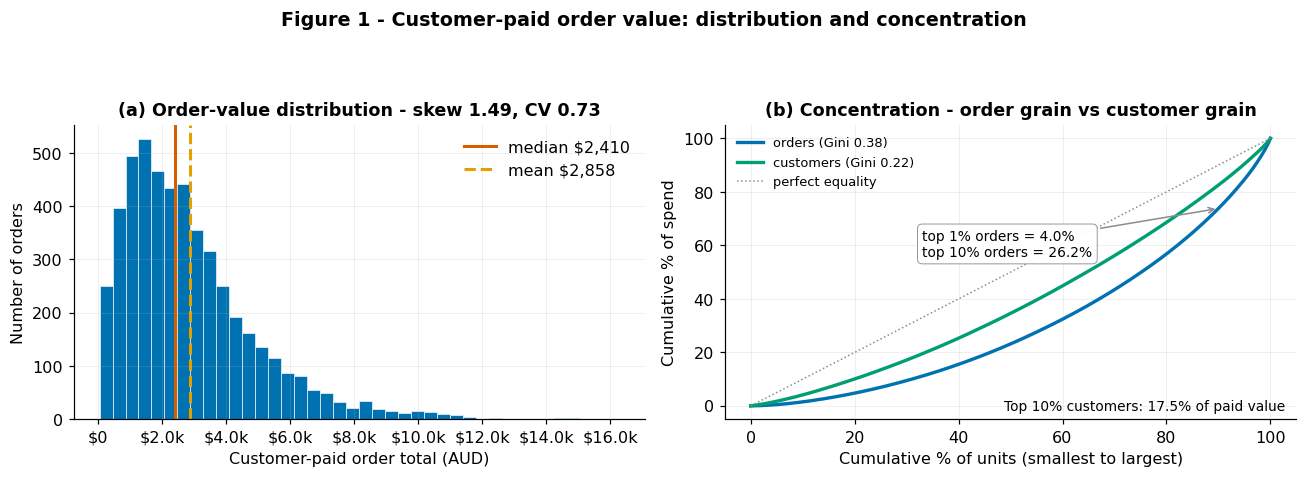

In [4]:
# order_total is the customer-paid total (includes delivery, net of coupon) - not merchandise revenue.
paid = orders['order_total']
x = np.sort(paid.values); n = len(x)
gini_order = (2*np.sum(np.arange(1,n+1)*x)/(n*x.sum())) - (n+1)/n
top1 = x[int(np.ceil(0.99*n)):].sum()/x.sum()*100
top10 = x[int(np.ceil(0.90*n)):].sum()/x.sum()*100

# Correct grain for a resilience claim: paid value per CUSTOMER.
cust_rev = orders.groupby('customer_id')['order_total'].sum().sort_values()
cx = cust_rev.values; cn = len(cx)
gini_cust = (2*np.sum(np.arange(1,cn+1)*cx)/(cn*cx.sum())) - (cn+1)/cn
c_top10 = cx[int(np.ceil(0.90*cn)):].sum()/cx.sum()*100

fig, ax = plt.subplots(1, 2, figsize = (12, 4.3))
# Panel (a): Distribution with both mean and median (skewed monetary field = > report both).
ax[0].hist(paid, bins = 40, color = OK['blue'], edgecolor = 'white', linewidth = 0.4)
ax[0].axvline(paid.median(), color = OK['verm'],  lw = 2, label = f"median ${paid.median():,.0f}")
ax[0].axvline(paid.mean(),   color = OK['orange'], lw = 2, ls = '--', label = f"mean ${paid.mean():,.0f}")
ax[0].set(xlabel = 'Customer-paid order total (AUD)', ylabel = 'Number of orders',
          title = f'(a) Order-value distribution - skew {paid.skew():.2f}, CV {paid.std()/paid.mean():.2f}')
ax[0].xaxis.set_major_formatter(FuncFormatter(aud)); ax[0].legend(loc = 'upper right')

# Panel (b): Concentration at ORDER vs CUSTOMER grain.
ax[1].plot(np.concatenate([[0], np.arange(1,n+1)/n*100]), np.concatenate([[0], np.cumsum(x)/x.sum()*100]), color = OK['blue'], lw = 2.2,
           label = f'orders (Gini {gini_order:.2f})')
ax[1].plot(np.concatenate([[0], np.arange(1,cn+1)/cn*100]), np.concatenate([[0], np.cumsum(cx)/cx.sum()*100]), color = OK['green'], lw = 2.2,
           label = f'customers (Gini {gini_cust:.2f})')
ax[1].plot([0,100],[0,100], color = OK['grey'], lw = 1, ls = ':', label = 'perfect equality')
ax[1].set(xlabel = 'Cumulative % of units (smallest to largest)', ylabel = 'Cumulative % of spend',
          title = '(b) Concentration - order grain vs customer grain')
# White bbox: the dotted equality line runs diagonally through this region, so the
# annotation needs an opaque backing to stay readable at 100% zoom.
ax[1].annotate(f'top 1% orders = {top1:.1f}%\ntop 10% orders = {top10:.1f}%',
               xy = (90, 100-top10), xytext = (33, 56), fontsize = 9,
               bbox = dict(boxstyle = 'round,pad=0.35', facecolor = 'white',
                           edgecolor = OK['grey'], linewidth = .6, alpha = .95),
               arrowprops = dict(arrowstyle = '->', color = OK['grey']))
ax[1].legend(loc = 'upper left', fontsize = 8.5)
ax[1].text(.98,.03,f'Top 10% customers: {c_top10:.1f}% of paid value',
           transform=ax[1].transAxes,ha='right',fontsize=9)
fig.suptitle('Figure 1 - Customer-paid order value: distribution and concentration',
             fontsize = 12.5, fontweight = 'bold', y = 1.00)
finish(fig,1)

### Figure 2: Quantity × weighted price and gross value (multivariate)
**Question:** How do quantity and weighted unit price jointly structure gross merchandise value?

**Observation unit and denominator:** one order, **n = 5,000**; each heatmap cell reports the median and its order count.

**Tables and join keys:** `order_items` aggregated to order grain, then joined to `orders` on `order_id` (**one-to-one**).

**Interpretation:** Order quantity and quantity-weighted unit price **reconstruct the accounting identity** gross merchandise value = quantity × weighted price. Aggregating item lines before a validated one-to-one order join preserves the order grain; the *heatmap* compares both dimensions simultaneously, *cell medians* reduce sensitivity to extreme values, and *cell counts* disclose comparison support. Across 5,000 orders, **median gross value increases along both dimensions**, from \\$627 to \\$8,739 between opposite corners. A log-variance decomposition adds descriptive structure: read as **additive algebraic shares of var(log gross value)** - not independent importance weights, a fitted-model R², or causal contributions - quantity-weighted unit price accounts for 57.0%, quantity 32.1% and twice their covariance 10.9%. **Weighted-price (basket-price) composition therefore accounts for more of the observed proportional value dispersion** than differences in units purchased, motivating **product-mix investigation** rather than an immediate price-increase recommendation.

**Limitation:** gross value = quantity × weighted unit price is an arithmetic identity, not a causal model: weighted price reflects product mix and within-product price variation, medians conceal dispersion, the quantity bins are discreteness-driven groups rather than equal-count quartiles, and the variance shares carry no uncertainty estimate. Because gross merchandise value excludes discounts and delivery charges, the results do not establish net revenue or profitability.

Order composition: left = 5000, output = 5000, unmatched = 0, contract = one_to_one


,component,share_of_log_variance_%
0,weighted unit price,57.0
1,quantity,32.1
2,covariance (2x),10.9
3,total,100.0


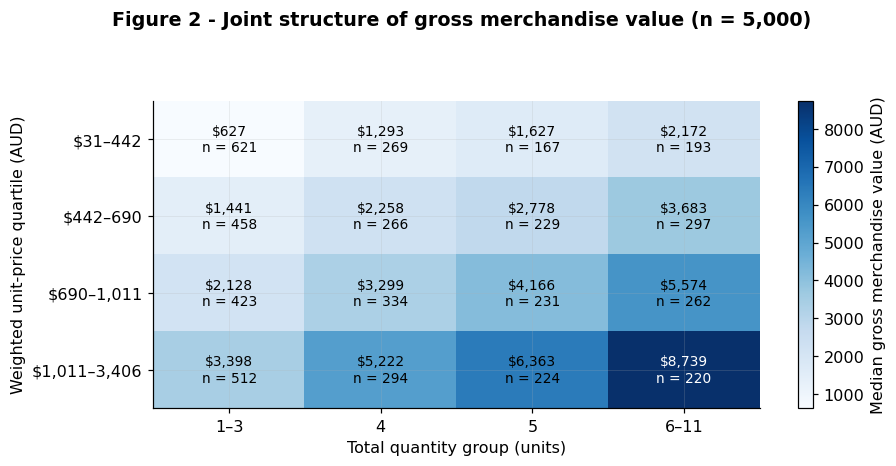

In [5]:
per_order = order_items.groupby('order_id').agg(qty = ('quantity','sum'),line = ('line_revenue','sum'),nlines = ('order_item_id','size')).reset_index()

# Quantity-weighted unit price = sum(line_revenue) / sum(quantity), NOT a simple mean of unit prices.
o2 = join_audit(orders,per_order,'order_id',name = 'Order composition',validate = 'one_to_one')
o2['wap'] = o2.line/o2.qty
lp,lw,lq = np.log(o2.order_price),np.log(o2.wap),np.log(o2.qty)
shares = np.array([lw.var(),lq.var(),2*np.cov(lw,lq)[0,1]])/lp.var()*100
assert np.isclose(shares.sum(),100)

# Log-variance decomposition quoted in the interpretation: var(log price) + var(log qty)
# + 2*cov, each as a share of var(log gross value). Displayed so the figures in the text
# are reproduced rather than asserted.
decomp = pd.DataFrame({'component': ['weighted unit price', 'quantity', 'covariance (2x)', 'total'],
                       'share_of_log_variance_%': np.round(np.append(shares, shares.sum()), 1)})
display(decomp)

# Figure 2 - Structural surface: median gross merchandise value by quantity x weighted-price bin.
o2['qgroup'] = pd.qcut(o2.qty,4,duplicates = 'drop')
o2['pgroup'] = pd.qcut(o2.wap,4,duplicates = 'drop')
heat = o2.pivot_table(index = 'pgroup',columns = 'qgroup',values = 'order_price',aggfunc = 'median',observed = True)
counts = o2.pivot_table(index = 'pgroup',columns = 'qgroup',values = 'order_id',aggfunc = 'size',observed = True).reindex_like(heat)
fig,ax = plt.subplots(figsize = (8.5,4.2))
im = ax.imshow(heat,cmap = 'Blues',aspect = 'auto')

for i in range(len(heat)):
    for j in range(len(heat.columns)):
        v = heat.iloc[i,j]; nn = counts.iloc[i,j]
        if pd.notna(v): ax.text(j,i,f'${v:,.0f}\nn = {int(nn)}',ha = 'center',va = 'center',fontsize = 9,color = 'white' if v>(np.nanmin(heat)+.72*(np.nanmax(heat)-np.nanmin(heat))) else 'black')

ax.set_xticks(range(len(heat.columns)),[str(int(o2.loc[o2.qgroup == v,'qty'].min())) if o2.loc[o2.qgroup == v,'qty'].min() == o2.loc[o2.qgroup == v,'qty'].max() else f'{int(o2.loc[o2.qgroup == v,"qty"].min())}–{int(o2.loc[o2.qgroup == v,"qty"].max())}' for v in heat.columns])
ax.set_yticks(range(len(heat)),[f'${o2.loc[o2.pgroup == v,"wap"].min():,.0f}–{o2.loc[o2.pgroup == v,"wap"].max():,.0f}' for v in heat.index])
ax.set(xlabel = 'Total quantity group (units)',ylabel = 'Weighted unit-price quartile (AUD)')
fig.colorbar(im,ax = ax,label = 'Median gross merchandise value (AUD)')
fig.suptitle(f'Figure 2 - Joint structure of gross merchandise value (n = {len(o2):,})', fontsize = 12.5, fontweight = 'bold', y = 1.00)
finish(fig,2)

### Figure 3 - Category sales and contribution proxy (composition/group comparison)

**Question:** Which categories account for merchandise value and recorded contribution?

**Observation unit and denominator:** item lines aggregated by category; rates divide the category contribution proxy by discounted category sales.

**Tables and join keys:** `order_items` joins `products` on `product_id`, then `orders` on `order_id` (both **many-to-one**).

**Interpretation:** In this export, **absolute category contribution mainly reflects differences in sales scale**, not the modest differences in retained rates. A paired aligned bar compares category monetary scale and contribution rate on separate labelled axes; ordering by contribution supports portfolio comparison. Across 15,739 item lines, **discounted sales vary about fivefold** (\\$512k for Accessory to \\$2.57M for Laptop), while contribution-proxy rates cluster within a narrow 4.5 percentage-point band (28.6%–33.1%; weighted portfolio rate ~31.2%). This is why Smart Home's highest rate (33.1%) does not overcome its smaller base, whereas Home Entertainment slightly surpasses Laptop in absolute contribution (\\$787.7k vs \\$781.5k) despite lower sales, and Gaming ranks third on the weakest rate - **sales scale can outweigh rate differences**. The analysis identifies where recorded contribution currently sits, not which category offers the greatest growth opportunity or investment return.

**Limitation:** these are operational proxies, neither accounting profit nor a verified upper bound. GST-inclusive sales and an unverified unit-cost tax basis may distort margins, and a uniform percentage-coupon allocation assumes the discount applies across all lines, which can misrepresent targeted promotions. A small aggregate cent-rounding residual (AUD ~0.14 across all orders) is reported in code and does not change category totals or rankings. Verify tax consistency, discount allocation and relevant costs before using contribution magnitudes or category rankings for strategic decisions.

Figure 3 items × products: left = 15739, output = 15739, unmatched = 0, contract = many_to_one
Figure 3 items × orders: left = 15739, output = 15739, unmatched = 0, contract = many_to_one
Coupon-allocation residual: AUD 0.136 aggregate (order-level cent rounding; does not change category totals or rankings).


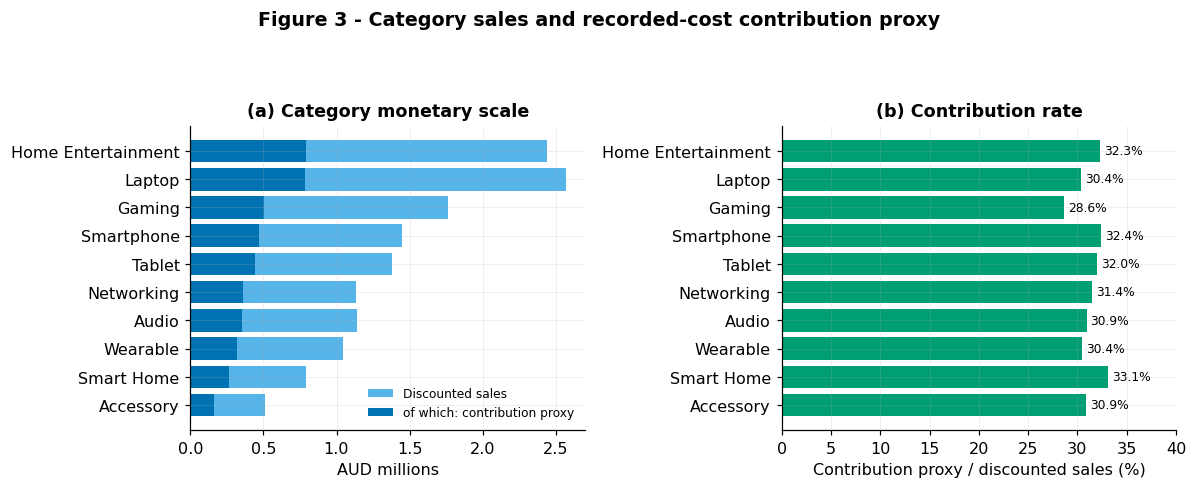

,realised_rev,contribution,units,margin_%,rev_share
category,,,,,
Home Entertainment,2437486.624,787683.344,1396,32.315,17.141
Laptop,2571157.274,781500.984,1363,30.395,18.081
Gaming,1765578.384,505235.924,1638,28.616,12.416
Smartphone,1445622.256,468832.696,1610,32.431,10.166
Tablet,1379826.151,441456.551,1766,31.994,9.703
Networking,1135649.746,357106.716,2033,31.445,7.986
Audio,1140253.652,352624.112,2336,30.925,8.018
Wearable,1045118.714,318181.784,2302,30.445,7.349
Smart Home,787640.470,260629.450,2630,33.090,5.539


**Interpretation:** Across 15,739 item lines and 10 categories, discounted sales span 5.0× while contribution proxy rates span 28.6–33.1%. Laptop leads sales; Home Entertainment leads contribution. Scale is central to portfolio interpretation, but rates can reorder similarly sized categories. These observed rankings identify where recorded contribution sits, not which investment will generate the greatest return.

In [6]:
# JOIN 1 (audited): items -> products (product_id unique -> no multiplication).
# JOIN 2 (audited): items -> orders' coupon (order_id unique -> no multiplication).
ip = join_audit(order_items, products[['product_id','category','unit_cost']], 'product_id', name = 'Figure 3 items × products')
ip = join_audit(ip, orders[['order_id','coupon_discount']], 'order_id', name = 'Figure 3 items × orders')
ip['realised_rev'] = ip['line_revenue'] * (1 - ip['coupon_discount']/100)   # revenue net of allocated discount
ip['contribution'] = ip['realised_rev'] - ip['unit_cost']*ip['quantity']
cat = (ip.groupby('category')
       .agg(realised_rev = ('realised_rev','sum'), contribution = ('contribution','sum'), units = ('quantity','sum'))
       .sort_values('contribution', ascending = False))
cat['margin_%'] = cat['contribution']/cat['realised_rev']*100
cat['rev_share'] = cat['realised_rev']/cat['realised_rev'].sum()*100

# Rounding transparency: allocated discounted line revenue vs order paid value net of delivery charges.
_alloc = ip['realised_rev'].sum(); _paid_ex_delivery = (orders['order_total'] - orders['delivery_charges']).sum()
print(f'Coupon-allocation residual: AUD {_alloc - _paid_ex_delivery:,.3f} aggregate (order-level cent rounding; does not change category totals or rankings).')

fig,ax = plt.subplots(1,2,figsize = (11,4.4))
y = np.arange(len(cat))
ax[0].barh(y,cat.realised_rev/1e6,color = OK['sky'],label = 'Discounted sales')
ax[0].barh(y,cat.contribution/1e6,color = OK['blue'],label = 'of which: contribution proxy')
ax[0].set_yticks(y,cat.index); ax[0].invert_yaxis(); ax[0].set(xlabel = 'AUD millions',title = '(a) Category monetary scale'); ax[0].legend(loc = 'lower right', fontsize = 8)
ax[1].barh(y,cat['margin_%'],color = OK['green']); ax[1].set_yticks(y,cat.index); ax[1].invert_yaxis()
ax[1].set(xlabel = 'Contribution proxy / discounted sales (%)',title = '(b) Contribution rate',xlim = (0,40))
for i,v in enumerate(cat['margin_%']): ax[1].text(v+.4,i,f'{v:.1f}%',va = 'center',fontsize = 8)
fig.suptitle('Figure 3 - Category sales and recorded-cost contribution proxy', fontsize = 12.5, fontweight = 'bold', y = 1.00)
finish(fig,3)

display(cat.round(3))

report(f'**Interpretation:** Across {len(ip):,} item lines and {len(cat)} categories, discounted sales span {cat.realised_rev.max()/cat.realised_rev.min():.1f}× while contribution proxy rates span {cat["margin_%"].min():.1f}–{cat["margin_%"].max():.1f}%. {cat.realised_rev.idxmax()} leads sales; {cat.contribution.idxmax()} leads contribution. Scale is central to portfolio interpretation, but rates can reorder similarly sized categories. These observed rankings identify where recorded contribution sits, not which investment will generate the greatest return.')

## Theme B - Review representation and experience

### Figure 4: Coverage within line-count strata and by item price (multivariate/review)

**Question:** Does review coverage increase with value within equal item-line counts?

**Observation unit and denominator:** Panel A: orders within exact line-count strata and within-stratum paid-value quartiles. Panel B: item lines by unit-price quartile; numerators are item lines with ≥1 review.

**Tables and join keys:** Order-item counts → orders on `order_id`; review presence via `order_id` / `order_item_id`; `category` from products on `product_id` (many-to-one). Order counts are aggregated before a one-to-one order join; membership flags cannot multiply rows.

**Interpretation:** **The multi-grain dual visualisation is used**, comprising panel A plotting **stratified lines** to assess whether the value association persists at equal item-line counts while **item-level cluster-bootstrapped error bars** (panel B) illustrate uncertainty accounting for within-order dependence. Among three-line orders, coverage rises from 74.2% to 92.0% across value quartiles (+17.8 percentage points), so opportunity count alone cannot explain the gradient. Across 15,739 item lines, coverage increases from 27.0% to 63.6% across price quartiles (+36.6 percentage points; 2.35×). **Higher-priced items also receive more reviews within all ten categories**, weakening category composition as the sole explanation. Reviews therefore disproportionately represent higher-value purchases, limiting their representativeness of the overall purchase mix.
 
**Limitation:** Equal line count does not control category/customer composition or review follow-up. Item intervals resample orders (3,000 draws, fixed price cutpoints); repeated customers remain a dependence limitation. Panel A is descriptive, with cell denominators in the supporting table.

Item unit-price quartile cutpoints (AUD): [21.4, 234.12, 543.69, 1062.27, 4090.98]


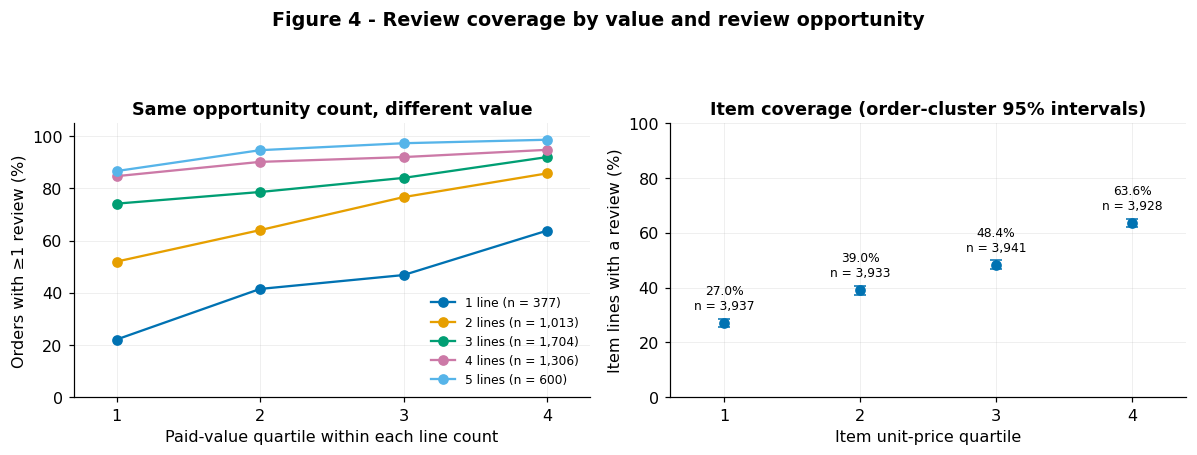

sum  size      mean
nlines value_q                     
1      1         21    95  0.221053
       2         39    94  0.414894
       3         44    94  0.468085
       4         60    94  0.638298
2      1        132   254  0.519685
       2        162   253  0.640316
       3        194   253  0.766798
       4        217   253  0.857708
3      1        316   426  0.741784
       2        335   426  0.786385
       3        358   426  0.840376
       4        392   426  0.920188
4      1        277   327  0.847095
       2        294   326  0.901840
       3        300   326  0.920245
       4        310   327  0.948012
5      1        130   150  0.866667
       2        142   150  0.946667
       3        146   150  0.973333
       4        148   150  0.986667

,sum,size,mean
price_q,,,
1,1064,3937,0.270257
2,1532,3933,0.389525
3,1906,3941,0.483634
4,2498,3928,0.635947


mean            size      
higher_price           False     True  False True 
category                                          
Accessory           0.236066  0.357202  1220  1201
Audio               0.349119  0.456180   908   890
Gaming              0.441176  0.607477   646   642
Home Entertainment  0.478182  0.737037   550   540
Laptop              0.603416  0.690840   527   524
Networking          0.352651  0.535354   811   792
Smart Home          0.286957  0.405797  1035  1035
Smartphone          0.444444  0.652866   648   628
Tablet              0.426492  0.616071   687   672
Wearable            0.331498  0.469714   908   875

**Takeaway:** within three-line orders, lowest/highest value-quartile coverage is 74.2%/92.0%. At item grain, coverage rises 27.0% → 63.6% across unit-price quartiles. Holding line count fixed does not remove the value association; follow-up and customer composition remain unresolved.

In [7]:
# Panel A (order grain): within each exact line-count stratum, split orders into within-stratum
#   paid-value quartiles. Holding line count fixed removes the "more lines -> more chances to be
#   reviewed" explanation, so a residual value gradient is not removed by stratification on line count.
o2['reviewed'] = o2.order_id.isin(reviews.order_id)
o2['value_q']  = (o2.groupby('nlines').order_total
                    .transform(lambda s: pd.qcut(s, 4, labels=False, duplicates='drop')) + 1)
coverage = o2.groupby(['nlines', 'value_q']).reviewed.agg(['sum', 'size', 'mean'])

# Panel B (item grain): coverage of individual item lines by unit-price quartile.
ip['reviewed'] = ip.order_item_id.isin(reviews.order_item_id)
ip['price_q']  = pd.qcut(ip.unit_price, 4, labels=False, duplicates='drop') + 1
print('Item unit-price quartile cutpoints (AUD):', [round(float(v), 2) for v in ip.unit_price.quantile([0, .25, .5, .75, 1])])
item_cov = ip.groupby('price_q').reviewed.agg(['sum', 'size', 'mean'])

# Order-cluster bootstrap for the item-grain rates: resample whole ORDERS (not items) so that
# within-order dependence is respected; unit-price cutpoints stay fixed across resamples.
cluster = ip.groupby(['order_id', 'price_q']).reviewed.agg(['sum', 'size']).unstack(fill_value=0)
num = cluster['sum'].reindex(columns=item_cov.index, fill_value=0).to_numpy()
den = cluster['size'].reindex(columns=item_cov.index, fill_value=0).to_numpy()
rng_cov = np.random.default_rng(5197)
draws = []
for _ in range(3000):
    ix = rng_cov.integers(0, len(cluster), len(cluster))
    draws.append(num[ix].sum(0) / den[ix].sum(0))
coverage_ci = np.quantile(draws, [.025, .975], axis=0)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.1))

# Panel A - one line per item-count stratum; a rising slope means value still matters at fixed opportunity.
for j, (lines, g) in enumerate(coverage.groupby(level=0)):
    q = g.index.get_level_values(1)
    ax[0].plot(q, g['mean'] * 100, 'o-', color=SEG[j % len(SEG)],
               label=f'{lines} line{"" if lines == 1 else "s"} (n = {g["size"].sum():,})')
ax[0].set(xticks=[1, 2, 3, 4], xlim=(0.7, 4.3), xlabel='Paid-value quartile within each line count',
          ylabel='Orders with ≥1 review (%)', ylim=(0, 105),
          title='Same opportunity count, different value')
ax[0].legend(loc='lower right', fontsize=8)
# Panel B - item-grain coverage by unit-price quartile, with order-cluster 95% intervals.
for q, r in item_cov.iterrows():
    p = r['mean']; lo, hi = coverage_ci[:, list(item_cov.index).index(q)]
    ax[1].errorbar(q, p * 100, yerr=[[(p - lo) * 100], [(hi - p) * 100]],
                   fmt='o', capsize=4, color=OK['blue'])
    ax[1].text(q, p * 100 + 5, f'{p*100:.1f}%\nn = {int(r["size"]):,}', ha='center', fontsize=8)
ax[1].set(xticks=[1, 2, 3, 4], xlim=(0.6, 4.4), xlabel='Item unit-price quartile',
          ylabel='Item lines with a review (%)', ylim=(0, 100),
          title='Item coverage (order-cluster 95% intervals)')
fig.suptitle('Figure 4 - Review coverage by value and review opportunity', fontsize = 12.5, fontweight = 'bold', y = 1.00)
finish(fig, 4)
display(coverage); display(item_cov)

# Robustness - within each category, do above-median-priced item lines get more coverage than at/below-median ones? (within-category median split; ties fall in the at/below group)
ip['higher_price'] = ip.unit_price > ip.groupby('category').unit_price.transform('median')
within_cat = ip.groupby(['category', 'higher_price']).reviewed.agg(['mean', 'size']).unstack()
display(within_cat)

report(f'**Takeaway:** within three-line orders, lowest/highest value-quartile coverage is '
       f'{coverage.loc[(3,1),"mean"]*100:.1f}%/{coverage.loc[(3,4),"mean"]*100:.1f}%. At item grain, coverage '
       f'rises {item_cov.iloc[0]["mean"]*100:.1f}% → {item_cov.iloc[-1]["mean"]*100:.1f}% across unit-price '
       f'quartiles. Holding line count fixed does not remove the value association; follow-up and customer '
       f'composition remain unresolved.')

### Figure 5: Rating distribution by value experience (bivariate/review)

**Question:** How does the full rating distribution differ between reported good and poor value?

**Observation unit and denominator:** Reviews, clustered within orders; each review receives equal weight.

**Tables and join keys:** `product_reviews` for the rating distribution, with `order_id` defining the bootstrap clusters. The two marginal statistics add one audited **many-to-one** join each on `order_id`: `product_reviews` → `orders` for `order_total`, and `product_reviews` → `deliveries` for `on_time_in_full`. Both parents are unique on `order_id`, so neither join can multiply review rows (7,000 in, 7,000 out, 0 unmatched, reported by `join_audit`).

**Interpretation:** The 100% stacked bars are chosen to **preserve ordinal composition**: both value groups record approximately 65.9% four-or-five-star ratings, yet good-value reviews have a 12.7-percentage-point higher five-star share (34.5% versus 21.8%). Binary satisfaction reporting therefore conceals differences in rating intensity. The mean advantage is statistically distinguishable from zero (0.18 stars; order-cluster 95% CI [0.09, 0.27]), but Cliff’s δ = 0.093 indicates weak ordinal separation. This is a **cross-sectional composition difference** between the good- and poor-value review groups, not the same customers moving between four and five stars. Perceived value distinguishes top-end ratings modestly; it does not strongly separate overall satisfaction. *(Separate marginal checks - rating vs paid order value and rating vs OTIF - are small in this export (r = −0.019; Cliff's δ = 0.031) and are reported in the Supplementary section; they describe marginal context only and do not adjust or test the value-perception association.)*
 
**Limitation:** Value experience and rating are co-reported, so response framing and selective review participation prevent causal or population-level inference. The 6,118:882 imbalance affects precision but does not prove selection. Order-cluster resampling handles within-order dependence, not repeat-customer dependence. Treating stars as equally spaced affects the mean gap; Cliff’s δ mitigates that assumption. Exclude value experience from pre-purchase models because it is unavailable at decision time and would cause leakage.

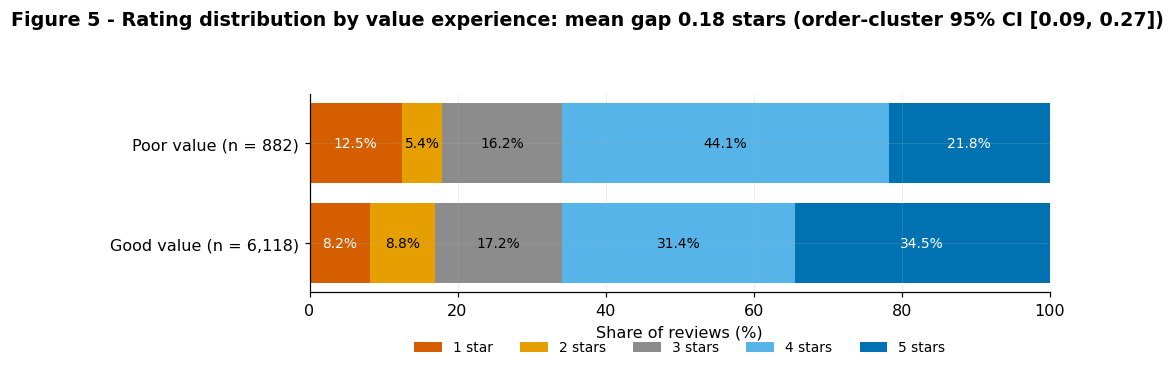

Cliff delta = 0.093; ≥4 stars: 65.85% vs 65.87%; bootstrap orders = 4017


**Takeaway:** ≥4-star shares are almost equal, but 5-star shares are 34.5% versus 21.8% (gap 12.7 pp). Top-two-box aggregation hides the 4/5-star composition. Mean gap 0.179 stars, order-cluster CI [0.092, 0.267]; co-reporting prevents causal inference.

In [8]:
gv = reviews.loc[reviews.value_experience == 'good_value', 'rating']
pv = reviews.loc[reviews.value_experience == 'poor_value', 'rating']
assert len(gv) + len(pv) == len(reviews)

# Order-cluster bootstrap of the mean-star gap: reviews are grouped by order, so resample ORDERS.
# Per order, carry each value group's rating sum and count, then recombine after resampling.
g = reviews.assign(sg=np.where(reviews.value_experience == 'good_value', reviews.rating, 0),
                   ng=(reviews.value_experience == 'good_value').astype(int),
                   sp=np.where(reviews.value_experience == 'poor_value', reviews.rating, 0),
                   np_=(reviews.value_experience == 'poor_value').astype(int))
a = g.groupby('order_id')[['sg', 'ng', 'sp', 'np_']].sum().to_numpy()
rng = np.random.default_rng(5196)
boot = []
for _ in range(3000):
    t = a[rng.integers(0, len(a), len(a))].sum(axis=0)
    if t[1] and t[3]:
        boot.append(t[0] / t[1] - t[2] / t[3])

gap = gv.mean() - pv.mean()
rating_lo, rating_hi = np.quantile(boot, [.025, .975])
delta_val = cliffs_delta(gv, pv)

# (Marginal sensitivity checks moved to the Supplementary section so this assessed
# figure stays focused on the ordinal composition question.)

# Preserve all five ordinal levels; a top-two-box summary would hide the 4-vs-5-star shift.
dist = (pd.crosstab(reviews.value_experience, reviews.rating, normalize='index')
          .reindex(['good_value', 'poor_value'])
          .reindex(columns=range(1, 6), fill_value=0) * 100)

fig, ax = plt.subplots(figsize=(9, 3.5))
left = np.zeros(2)
for rating, color in zip(range(1, 6), [OK['verm'], OK['orange'], OK['grey'], OK['sky'], OK['blue']]):
    v = dist[rating].values
    ax.barh(range(2), v, left=left, color=color, label=f'{rating} star{"" if rating == 1 else "s"}')
    for i, p in enumerate(v):
        if p > 4:
            ax.text(left[i] + p / 2, i, f'{p:.1f}%', ha='center', va='center',
                    fontsize=9, color='white' if rating in [1, 5] else 'black')
    left += v

ax.set_yticks([0, 1], [f'Good value (n = {len(gv):,})', f'Poor value (n = {len(pv):,})'])
ax.set(xlim=(0, 100), xlabel='Share of reviews (%)')
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(.5, -.18), fontsize=9)
fig.suptitle(f'Figure 5 - Rating distribution by value experience: mean gap {gap:.2f} stars (order-cluster 95% CI [{rating_lo:.2f}, {rating_hi:.2f}])', fontsize = 12.5, fontweight = 'bold', y = 1.00)
finish(fig, 5)

print(f'Cliff delta = {delta_val:.3f}; ≥4 stars: {(gv >= 4).mean() * 100:.2f}% vs '
      f'{(pv >= 4).mean() * 100:.2f}%; bootstrap orders = {len(a)}')


report(f'**Takeaway:** ≥4-star shares are almost equal, but 5-star shares are {(gv == 5).mean() * 100:.1f}% '
       f'versus {(pv == 5).mean() * 100:.1f}% (gap {((gv == 5).mean() - (pv == 5).mean()) * 100:.1f} pp). '
       f'Top-two-box aggregation hides the 4/5-star composition. Mean gap {gap:.3f} stars, order-cluster CI '
       f'[{rating_lo:.3f}, {rating_hi:.3f}]; co-reporting prevents causal inference.')

## Theme C - Temporal and delivery operations

### Figure 6 - Calendar-exposure-normalised activity (temporal)

**Question:** How much do weekday and monthly order rates vary after calendar exposure?

**Observation unit and denominator:** Orders per calendar day in each weekday/month; zero-order dates included.

**Tables and join keys:** `orders.order_timestamp`; no join.

**Interpretation:** Calendar-normalised means correctly use calendar days-including zero-order dates-as denominators, preventing longer months or uneven weekday counts from inflating activity. **Day-of-week order rate is effectively flat:** 13.50–13.85 orders/day, only 2.6% apart. Monthly rates vary more, from 12.80 in September to 14.94 in August (16.7%, i.e. max/min − 1), but this contrast remains modest relative to daily variability (SD 3.55; Q1 = 11, Q3 = 16, so IQR = 5). The daily series and trailing seven-day mean show fluctuation rather than a clearly sustained trend. Observed weekday averages therefore differ little relative to day-to-day variability; whether calendar features improve next-day forecasts beyond simple baselines remains untested (MLQ-4), so these descriptive contrasts are not by themselves a forecasting or staffing signal.

**Limitation:** Only one 365-day window is observed, so apparent month differences cannot distinguish recurring seasonality from trend, promotions, holidays or random variation. Min/max timestamps may create partial boundary days, and zero-filling is valid only when missing dates genuinely represent zero orders. Daily aggregation conceals intraday peaks and batching. Without uncertainty estimates or out-of-sample validation, the observed calendar contrasts should not be treated as predictive effects.

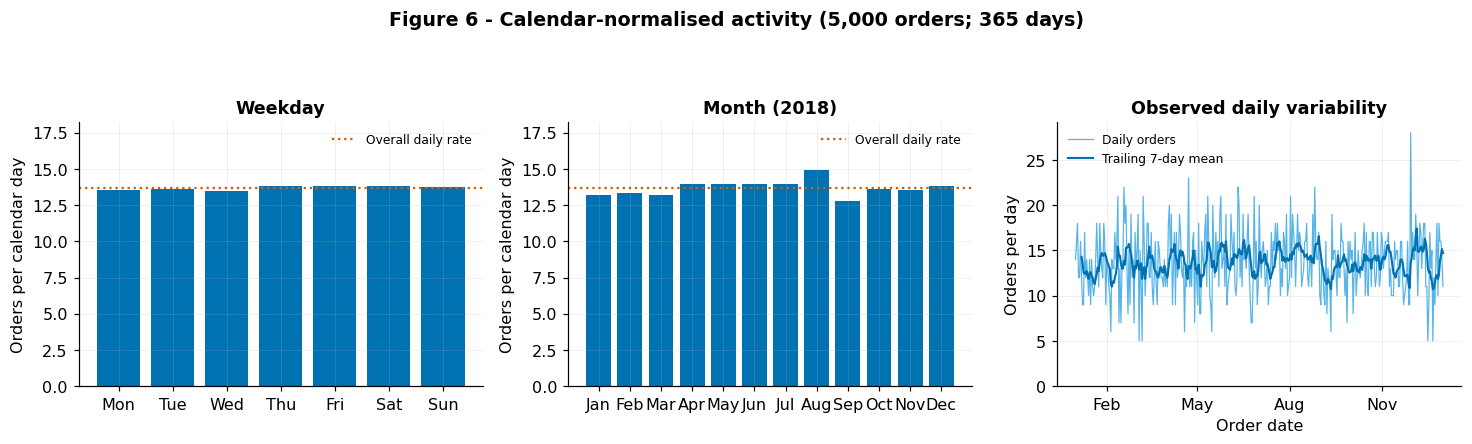

Weekday rates: {0: 13.566, 1: 13.635, 2: 13.5, 3: 13.846, 4: 13.808, 5: 13.808, 6: 13.731} Monthly rates: {1: 13.226, 2: 13.321, 3: 13.194, 4: 13.933, 5: 13.968, 6: 13.967, 7: 13.968, 8: 14.935, 9: 12.8, 10: 13.645, 11: 13.567, 12: 13.806}


,statistic,value
0,orders/day mean,13.70
1,orders/day SD,3.55
2,Q1,11
3,Q3,16
4,IQR (Q3-Q1),5
5,weekday range (max/min-1),2.6%
6,month range (max/min-1),16.7%


In [9]:
cal = pd.date_range(orders.order_dt.min().normalize(),orders.order_dt.max().normalize(),freq = 'D')
daily = orders.groupby(orders.order_dt.dt.normalize()).size().reindex(cal,fill_value = 0)
wd = daily.groupby(daily.index.dayofweek).mean().reindex(range(7))
mo = daily.groupby(daily.index.month).mean()
fig,ax = plt.subplots(1,3,figsize = (13.5,4.0))
for a,values,labels,title in [(ax[0],wd,['Mon','Tue','Wed','Thu','Fri','Sat','Sun'],'Weekday'),(ax[1],mo,[pd.Timestamp(2018,m,1).strftime('%b') for m in mo.index],'Month (2018)')]:
    a.bar(range(len(values)),values,color = OK['blue']); a.set_xticks(range(len(values)),labels)
    a.axhline(daily.mean(),ls = ':',color = OK['verm'],label = 'Overall daily rate')
    a.set(ylabel = 'Orders per calendar day',title = title,ylim = (0,max(wd.max(),mo.max())*1.22)); a.legend(fontsize = 8)
ax[2].plot(daily.index,daily.values,color=OK['sky'],lw=.8,label='Daily orders')
ax[2].plot(daily.index,daily.rolling(7,min_periods=7).mean(),color=OK['blue'],lw=1.4,label='Trailing 7-day mean')
ax[2].set(ylabel='Orders per day',xlabel='Order date',title='Observed daily variability',ylim=(0,None))
ax[2].xaxis.set_major_locator(mpl.dates.MonthLocator(interval=3))
ax[2].xaxis.set_major_formatter(mpl.dates.DateFormatter('%b'))
ax[2].legend(fontsize=8)
fig.suptitle(f'Figure 6 - Calendar-normalised activity ({len(orders):,} orders; {len(cal)} days)', fontsize = 12.5, fontweight = 'bold', y = 1.00)
finish(fig,6)
print('Weekday rates:',wd.round(3).to_dict(),'Monthly rates:',mo.round(3).to_dict())

# Day-level dispersion quoted in the interpretation. Reported alongside the group means
# because the calendar-normalised bars describe location only, not spread.
q1, q3 = daily.quantile(.25), daily.quantile(.75)
spread = pd.DataFrame({'statistic': ['orders/day mean', 'orders/day SD', 'Q1', 'Q3', 'IQR (Q3-Q1)',
                                     'weekday range (max/min-1)', 'month range (max/min-1)'],
                       'value': [f'{daily.mean():.2f}', f'{daily.std():.2f}', f'{q1:.0f}', f'{q3:.0f}',
                                 f'{q3-q1:.0f}', f'{(wd.max()/wd.min()-1)*100:.1f}%',
                                 f'{(mo.max()/mo.min()-1)*100:.1f}%']})
display(spread)

### Figure 7 - Recorded warehouse, service and OTIF (delivery/operational performance)

**Question:** Do OTIF rates differ across the recorded nearest-warehouse groups?

**Observation unit and denominator:** Deliveries; group successes / group deliveries.

**Tables and join keys:** deliveries joins orders on `order_id` (one-to-one).

**Interpretation:** Wilson intervals communicate binomial uncertainty; simultaneous warehouse-versus-rest contrasts control family-wise error, and service-tier stratification tests whether composition explains aggregate differences. OTIF varies overall (omnibus p = 0.0096): Nickolson records 92.2% (n = 898) versus Bakers 88.9% and Thompson 88.6%. Its +3.44-point contrast with all other orders remains positive after multiplicity adjustment (95% CI 0.77–5.70), whereas the other contrasts include zero. Nickolson also leads within Standard (92.2%) and Express (92.1%), so observed service mix does not explain its advantage. This identifies a targeted process-audit candidate, not proof that Nickolson operations caused better delivery.

**Limitation:** Nearest warehouse indicates proximity, not verified dispatch origin, so facility attribution may be wrong under rerouting or stockouts. Binary OTIF treats small and severe delays equally. Distance (available as `shipping_distance_km` but not adjusted for here), geography, courier, inventory and order complexity may explain differences; customer repetition also violates simple independence. Bonferroni intervals address multiple comparisons, not confounding. Analysing delay magnitude (`delay_days` is available) and verifying dispatch lineage, which may be genuinely unavailable, should precede operational intervention.

**Case-mix check:** show every recorded warehouse × service combination with denominators; common service weights standardise service composition only. This does not adjust other confounders.

Warehouse delivery: left = 5000, output = 5000, unmatched = 0, contract = one_to_one


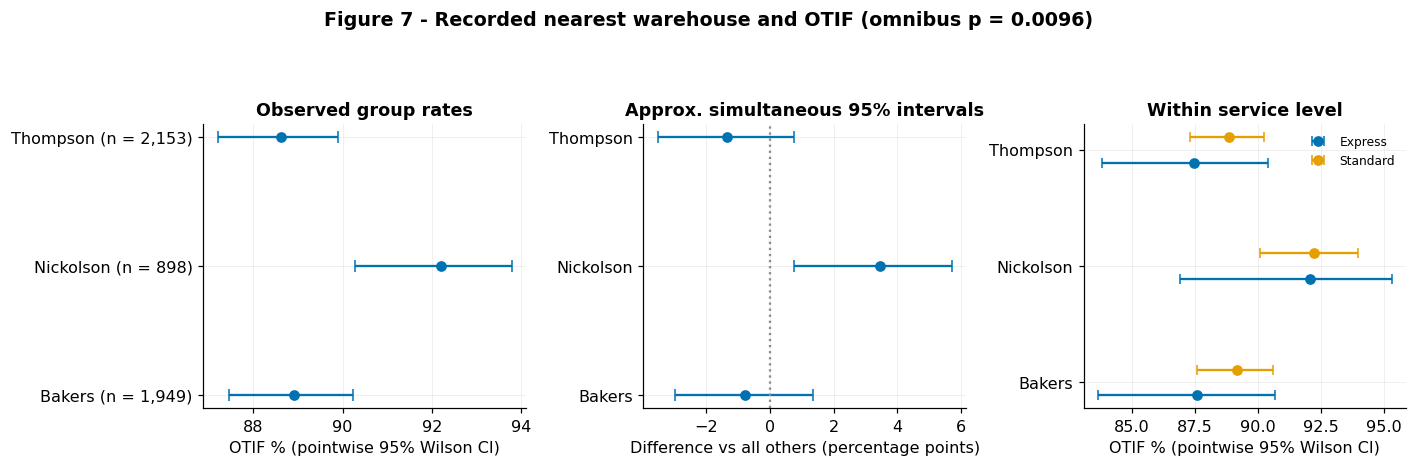

,sum,size,mean
nearest_warehouse,,,
Bakers,1733,1949,0.889174
Nickolson,828,898,0.922049
Thompson,1908,2153,0.886205


,difference,lo,hi
warehouse,,,
Bakers,-0.758123,-2.961458,1.356068
Nickolson,3.443320,0.774430,5.696070
Thompson,-1.333808,-3.489305,0.765513


sum  size      mean
nearest_warehouse service_level                      
Bakers            Express         297   339  0.876106
                  Standard       1436  1610  0.891925
Nickolson         Express         151   164  0.920732
                  Standard        677   734  0.922343
Thompson          Express         342   391  0.874680
                  Standard       1566  1762  0.888763

Rates standardised to overall service mix (descriptive, no causal interpretation):


nearest_warehouse
Bakers       0.889097
Nickolson    0.922055
Thompson     0.886245
dtype: float64

**Takeaway:** Nickolson-minus-other OTIF differences within service: Express +4.54 pp, Standard +3.21 pp. These are descriptive checks of service composition, not risk adjustment. The aggregate simultaneous interval accounts for the stated warehouse contrast family, not all exploratory analyses or customer clustering.

In [10]:
dd = join_audit(deliveries, orders[['order_id', 'nearest_warehouse']], 'order_id',
                name='Warehouse delivery', validate='one_to_one')
dd['ontime'] = dd.on_time_in_full.eq('True').astype(int)
# In THIS export OTIF and "not late" coincide; assert it so the shorthand is checked, not assumed.
assert dd.ontime.eq(dd.delay_days.le(0).astype(int)).all()

wh = dd.groupby('nearest_warehouse').ontime.agg(['sum', 'size', 'mean'])
chi_om, p_om, _, _ = stats.chi2_contingency(pd.crosstab(dd.nearest_warehouse, dd.ontime))

# Each warehouse vs the rest, as a Newcombe difference of Wilson limits, with a Bonferroni
# widening (z at alpha/2 split over every warehouse-vs-rest contrast) to acknowledge selection.
zsim = stats.norm.ppf(1 - .05 / (2 * len(wh)))
contrasts = []
for w, r in wh.iterrows():
    other = dd.loc[dd.nearest_warehouse != w, 'ontime']
    p, l, h = wilson(r['sum'], r['size'], zsim)
    q, ql, qh = wilson(other.sum(), len(other), zsim)
    d = p - q
    dl = d - np.sqrt((p - l)**2 + (qh - q)**2)
    dh = d + np.sqrt((h - p)**2 + (q - ql)**2)
    contrasts.append((w, d, dl, dh))
contrasts = pd.DataFrame(contrasts, columns=['warehouse', 'difference', 'lo', 'hi']).set_index('warehouse')

fig, ax = plt.subplots(1, 3, figsize=(13, 4.2))
# Panel (a) observed group rates; Panel (b) simultaneous difference-vs-rest intervals.
for i, (w, r) in enumerate(wh.iterrows()):
    p, l, h = wilson(r['sum'], r['size'])
    ax[0].errorbar(p * 100, i, xerr=[[(p - l) * 100], [(h - p) * 100]], fmt='o', capsize=4, color=OK['blue'])
    t = contrasts.loc[w]
    ax[1].errorbar(t.difference * 100, i, xerr=[[(t.difference - t.lo) * 100], [(t.hi - t.difference) * 100]],
                   fmt='o', capsize=4, color=OK['blue'])
ax[0].set_yticks(range(len(wh)), [f'{w} (n = {int(r["size"]):,})' for w, r in wh.iterrows()])
ax[0].set(xlabel='OTIF % (pointwise 95% Wilson CI)', title='Observed group rates')
ax[1].set_yticks(range(len(wh)), wh.index)
ax[1].axvline(0, color=OK['grey'], ls=':')
ax[1].set(xlabel='Difference vs all others (percentage points)', title='Approx. simultaneous 95% intervals')

# Panel (c) - case-mix check: OTIF within each warehouse x service-level cell.
service = dd.groupby(['nearest_warehouse', 'service_level']).ontime.agg(['sum', 'size', 'mean'])
levels = sorted(dd.service_level.unique())
for j, level in enumerate(levels):
    for i, w in enumerate(wh.index):
        r = service.loc[(w, level)]
        p, l, h = wilson(r['sum'], r['size'])
        yy = i + (j - (len(levels) - 1) / 2) * .22
        ax[2].errorbar(p * 100, yy, xerr=[[(p - l) * 100], [(h - p) * 100]],
                       fmt='o', capsize=3, color=SEG[j], label=level if i == 0 else None)
ax[2].set_yticks(range(len(wh)), wh.index)
ax[2].set(xlabel='OTIF % (pointwise 95% Wilson CI)', title='Within service level')
ax[2].legend(fontsize=8)
fig.suptitle(f'Figure 7 - Recorded nearest warehouse and OTIF (omnibus p = {p_om:.4f})', fontsize = 12.5, fontweight = 'bold', y = 1.00)
finish(fig, 7)
display(wh); display(contrasts * 100)
display(service)

# Descriptive service-mix standardisation (weights = overall service split) - not a causal adjustment.
weights = dd.service_level.value_counts(normalize=True)
std_rate = service['mean'].unstack().mul(weights).sum(axis=1)
print('Rates standardised to overall service mix (descriptive, no causal interpretation):')
display(std_rate)

# Nickolson-minus-other OTIF within each service level (composition check, not risk adjustment).
service_gaps = {}
for level in levels:
    a1 = dd.loc[(dd.nearest_warehouse == 'Nickolson') & (dd.service_level == level), 'ontime']
    a0 = dd.loc[(dd.nearest_warehouse != 'Nickolson') & (dd.service_level == level), 'ontime']
    service_gaps[level] = (a1.mean() - a0.mean()) * 100
report('**Takeaway:** Nickolson-minus-other OTIF differences within service: '
       + ', '.join(f'{k} {v:+.2f} pp' for k, v in service_gaps.items())
       + '. These are descriptive checks of service composition, not risk adjustment. The aggregate '
         'simultaneous interval accounts for the stated warehouse contrast family, not all exploratory '
         'analyses or customer clustering.')

### Figure 8 - Delivery cost recovery by service (delivery/operational performance)

**Question:** How do charges compare with recorded delivery costs across services?

**Observation unit and denominator:** deliveries; recovery = sum(charges) / sum(recorded costs), not the average of individual order ratios.

**Tables and join keys:** `deliveries` → `orders` on `order_id` (**one-to-one**).

**Interpretation:** the two panels separate order-level dollar exposure from service-level recovery; using sum(charges)/sum(costs) rather than a mean of order ratios gives the cost-weighted portfolio measure. Across 5,000 matched deliveries, charges exceed recorded delivery costs by \\$15,095, and all order-level differences are positive (minimum \\$0.61; median \\$2.74), though the contribution distribution is right-skewed. Standard recovers \\$1.27 per \\$1 of recorded cost (n = 4,106; median contribution \\$2.49) versus \$1.28 for Express (n = 894; median \\$4.94). The recovery gap between tiers is 0.009× (1.28× vs 1.27×): Express's larger dollar contribution mainly reflects higher transaction scale, while both tiers show broadly similar markups over recorded cost. Whether that gap is economically material needs a decision threshold not available here.

**Limitation:** recorded delivery cost may exclude packing, labour, materials, failed deliveries, returns and shared overhead, so contribution is neither logistics profit nor a verified economic floor. GST treatment of charges and costs is unresolved. The figure offers no uncertainty, distance adjustment, demand response or counterfactual pricing, and service selection may reflect different routes or customers. It demonstrates recorded-cost recovery only - not optimal fees, causal service effects or full-cost profitability.

Figure 8 deliveries × orders: left = 5000, output = 5000, unmatched = 0, contract = one_to_one


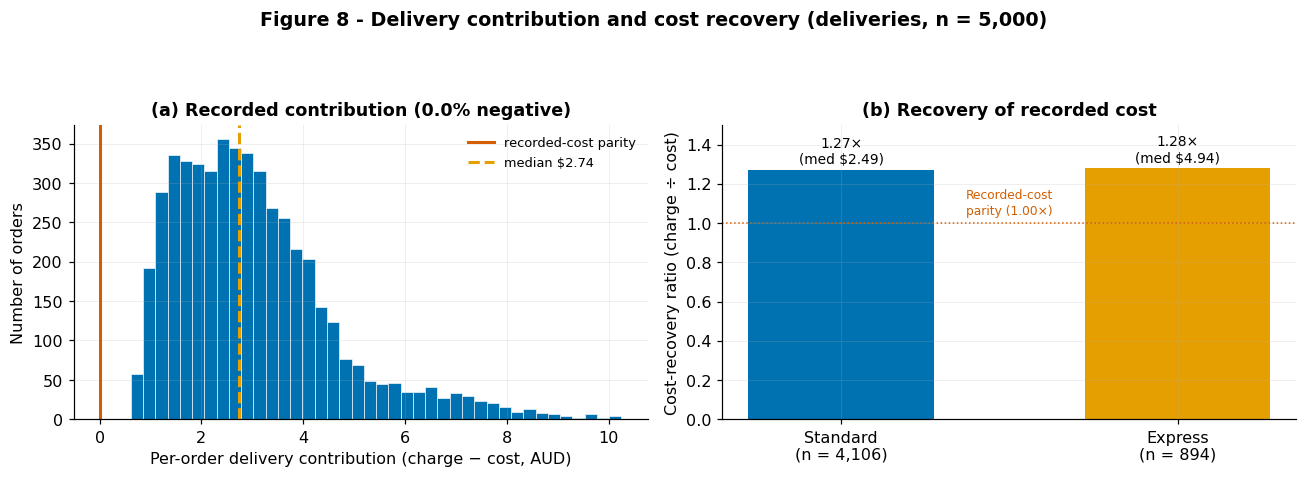

,n,charges,costs,median_contrib,recovery
service_level,,,,,
Express,894,20679.15,16148.80,4.945,1.281
Standard,4106,49451.56,38886.98,2.490,1.272


**Takeaway:** Across 5,000 deliveries, charges minus recorded costs total AUD 15,095, with median AUD 2.74, minimum AUD 0.61, and 0 negative records. Standard/Express recovery is 1.27×/1.28×; median contributions are AUD 2.49/4.94. Larger absolute Express contribution coexists with similar relative recovery. This supports checking economic scale and cost completeness, not a claim of optimal pricing.

In [11]:
dp = join_audit(deliveries[['order_id','delivery_cost','service_level','shipping_distance_km']],
                orders[['order_id','delivery_charges']], 'order_id', name = 'Figure 8 deliveries × orders', validate='one_to_one')
assert np.isfinite(dp['delivery_cost']).all() and (dp['delivery_cost'] > 0).all(), 'delivery_cost must be finite and positive before loss_share/ratio aggregation'
dp['contrib'] = dp['delivery_charges'] - dp['delivery_cost']
loss_share = (dp['contrib'] < 0).mean()*100

fig, ax = plt.subplots(1, 2, figsize = (12, 4.3))
# (a) Contribution distribution + negative recorded contribution share.
ax[0].hist(dp['contrib'], bins = 40, color = OK['blue'], edgecolor = 'white', linewidth = 0.4)
ax[0].axvline(0, color = OK['verm'], lw = 2, label = 'recorded-cost parity')
ax[0].axvline(dp['contrib'].median(), color = OK['orange'], lw = 2, ls = '--', label = f"median ${dp['contrib'].median():.2f}")
ax[0].set(xlabel = 'Per-order delivery contribution (charge − cost, AUD)', ylabel = 'Number of orders',
          title = f'(a) Recorded contribution ({loss_share:.1f}% negative)')
ax[0].legend(loc = 'upper right', fontsize = 8.5)
# (b) Cost-recovery ratio by service level (charge/cost) - the like-for-like metric.
rec = dp.groupby('service_level').agg(n=('order_id','size'),charges=('delivery_charges','sum'),costs=('delivery_cost','sum'),median_contrib=('contrib','median'))
rec['recovery'] = rec.charges / rec.costs
LV = ['Standard','Express']
ax[1].bar(range(2), rec.loc[LV,'recovery'].values, color = [OK['blue'], OK['orange']], width = 0.55)
for i,l in enumerate(LV):
    ax[1].annotate(f"{rec.loc[l,'recovery']:.2f}×\n(med ${rec.loc[l,'median_contrib']:.2f})",
                   (i, rec.loc[l,'recovery']), xytext = (0,4), textcoords = 'offset points', ha = 'center', fontsize = 9)
ax[1].axhline(1.0, color = OK['verm'], ls = ':', lw = 1)
# Label the reference line in place rather than with a legend: legend(loc='best')
# only avoids lines and patches, not annotate() text, so it landed on the Express
# bar label. The gap between the two bars is the one region free at every height.
ax[1].text(0.5, 1.03, 'Recorded-cost\nparity (1.00×)', ha = 'center', va = 'bottom',
           fontsize = 8, color = OK['verm'], linespacing = 1.25)
ax[1].set_xticks(range(2)); ax[1].set_xticklabels([f'{l}\n(n = {int(rec.loc[l,"n"]):,})' for l in LV])
ax[1].set(ylabel = 'Cost-recovery ratio (charge ÷ cost)', ylim = (0,1.5),
          title = '(b) Recovery of recorded cost')
fig.suptitle('Figure 8 - Delivery contribution and cost recovery (deliveries, n = 5,000)',
             fontsize = 12.5, fontweight = 'bold', y = 1.00)
finish(fig,8)
display(rec.round(3))

report(f'**Takeaway:** Across {len(dp):,} deliveries, charges minus recorded costs total AUD {dp.contrib.sum():,.0f}, with median AUD {dp.contrib.median():.2f}, minimum AUD {dp.contrib.min():.2f}, and {(dp.contrib<0).sum()} negative records. Standard/Express recovery is {rec.loc["Standard","recovery"]:.2f}×/{rec.loc["Express","recovery"]:.2f}×; median contributions are AUD {rec.loc["Standard","median_contrib"]:.2f}/{rec.loc["Express","median_contrib"]:.2f}. Larger absolute Express contribution coexists with similar relative recovery. This supports checking economic scale and cost completeness, not a claim of optimal pricing.')


## Ten evidence-based findings

Values below are computed on this run. Export-wide descriptive statistics need no sampling interval to describe the observed export; generalisation requires assumptions. Inferential intervals are explicitly qualified in the figure notes.

1. **Finding 1: Large transactions do not establish dependence on a small customer elite.**
- Across 5,000 orders (500 customers), mean paid order value exceeds the median (\\$2,858 versus \\$2,410), but concentration falls at customer grain: the top 10% of orders contribute 26.2% of paid value, whereas the top 10% of customers contribute 17.5%, and the Gini falls from 0.38 (order grain) to 0.22 (customer grain). Transaction variability should therefore not be translated directly into a VIP-focused retention strategy. The unresolved question is whether high customer spending persists across periods or reflects occasional large baskets. *Evidence: Figure 1. → MLQ-1*

2. **Finding 2: Weighted price is the larger structural share of basket-value dispersion, but the accounting identity is not a predictive discovery.**
- At order grain (n = 5,000), quantity-weighted unit price contributes 57.0% of the log gross-value variance, versus quantity's 32.1% and twice their covariance 10.9% (additive algebraic shares of an identity, not importance weights). This supports examining what customers buy alongside how much they buy. However, weighted price is itself gross value divided by quantity, so predicting the same basket's gross value from these components would largely reconstruct an identity; a meaningful modelling task must instead predict future purchasing behaviour from information available beforehand. *Evidence: Figures 1–2 and the monetary safeguards. → MLQ-1*

3. **Finding 3: Commercial importance depends on sales scale and contribution rate jointly; neither ranking alone identifies an investment opportunity.**
- Across 15,739 item lines in ten categories, discounted sales span about 5.0× (\\$512k for Accessory to \\$2.57M for Laptop), while contribution-proxy rates range only 28.6%–33.1%. The much wider sales variation makes scale central to absolute contribution, although rate differences can still reorder similarly sized categories. Consequently a high-rate category is not automatically the largest contributor, and a large contributor is not automatically the best growth opportunity. Demand persistence and comparable costs must be established before translating portfolio rankings into investment priorities. *Evidence: Figures 2–3. → MLQ-1*

4. **Finding 4: Broad order-level feedback coverage conceals substantial gaps in product-level representation.**
- At least one review appears on 4,017 of 5,000 orders (80.3%), yet only 7,000 of 15,739 item lines (44.5%) are reviewed. These denominators answer different questions: an order can look represented while most of its purchased items remain unobserved, so order-level engagement is an inadequate assurance of product-feedback completeness. These are also **export-observed coverage rates, not verified eventual response rates** - the data contain orders through 2018-12-31, deliveries through 2019-01-10 and reviews through 2019-02-20, so the latest review is ~41 days after the latest delivery. Potential observation time and follow-up completeness must be established from the extraction contract before reading these as final response rates or defining mature 30-day cohorts; the observed price-coverage gradient does not depend on that verification. Review monitoring should assess item coverage explicitly, on a matured window, with separate checks across price and category. *Evidence: Figure 4A–B. → MLQ-2*

5. **Finding 5: Value-related review selection survives two separate composition checks, making representation a central analytical concern.**
- Within the 1,704 three-line orders (426 per within-stratum value quartile), review coverage rises from 74.2% to 92.0% across paid-value quartiles. At item grain, across all 15,739 item lines (about 3,935 per unit-price quartile), coverage rises from 27.0% to 63.6%, and higher-priced item lines have greater coverage within all ten categories (10 of 10 on a within-category median split). These are **two separate checks - holding line count fixed and splitting within category - not a single jointly adjusted control**, and together they weaken basket opportunity count and category composition as sole explanations. Higher-priced purchases are overrepresented in review data, but this does not establish that ratings are biased upward or downward; customer differences and unequal follow-up remain unresolved. *Evidence: Figure 4 and its supporting tables. → MLQ-2*

6. **Finding 6: Binary satisfaction conceals a small but statistically detectable ordinal shift alongside a sizeable five-star-share difference.**
- Across all 7,000 reviews, the 6,118 good-value and 882 poor-value reviews have virtually identical ≥4-star shares (65.85% versus 65.87%), but their five-star shares differ by 12.7 percentage points (34.5% versus 21.8%). The mean gap is 0.179 stars (order-cluster 95% CI [0.092, 0.267]) with Cliff's δ = 0.093 - a **small overall ordinal separation** despite the sizeable top-category difference. A binary favourable-rating metric therefore hides movement within favourable feedback; full ordinal outcomes are more informative, while the modest separation and co-reported labels limit causal reading. *Evidence: Figure 5. → MLQ-3*

7. **Finding 7: Review selection and rating intensity are distinct modelling targets.**
- The targets have different denominators. Review availability is measured over purchases: 4,017 of 5,000 orders (80.3%) carry a review, but only 7,000 of 15,739 item lines (44.5%) do, and item coverage ranges 27.0%–63.6% across price quartiles. Rating intensity is measured only over the 7,000 observed reviews, where value experience separates ratings weakly (Cliff's δ = 0.093, mean gap 0.179 stars); low ratings (≤2 stars) are 1,197 of 7,000 observed reviews (17.1%) but only 7.6% of all 15,739 purchased item lines, and an absent review is not positive satisfaction. A review-availability model (MLQ-2) therefore cannot be treated as a satisfaction model (MLQ-3), and ratings from reviewed items cannot be assumed representative of all purchases without addressing selection. *Evidence: Figures 4–5. → MLQ-2 and MLQ-3*

8. **Finding 8: Near-flat weekday averages do not imply a predictable daily workload.**
- Across 5,000 orders over 365 calendar days, weekday rates range only 13.50–13.85 orders/day, whereas daily counts have an SD of 3.55 (Q1 = 11, Q3 = 16, IQR = 5). Monthly rates vary more widely (12.80–14.94 orders/day), but one annual cycle cannot separate recurring seasonality from trend, promotions or noise. Staffing requires forecast-error and uncertainty assessment, not just average demand, and calendar features earn their place only if they improve future-period predictions over simple baselines - which the daily variability alone does not demonstrate. *Evidence: Figure 6. → MLQ-4*

9. **Finding 9: The warehouse-associated reliability difference survives service-mix checks, making it a priority for further investigation.**
- Of 5,000 completed-order deliveries, Nickolson records 92.2% OTIF on 898 deliveries versus 88.8% on the other 4,102: a 3.44-percentage-point difference with an approximate simultaneous 95% interval of [0.77, 5.70]. Its advantage persists within Express (+4.54 points) and Standard (+3.21 points), and service standardisation barely changes the observed rates, so service composition does not explain the aggregate difference. Geography, distance, customer dependence and other case mix remain unresolved, and `nearest_warehouse` must be verified as dispatch origin before attributing the association to fulfilment practices. *Evidence: Figure 7. → MLQ-5*

10. **Finding 10: Recorded delivery cost recovery and delivery reliability measure separate dimensions of operational performance.**
- Delivery charges exceed recorded costs on all 5,000 matched deliveries (0 negative), producing a \\$15,095 aggregate difference and a \\$2.74 median. Standard (n = 4,106) and Express (n = 894) recover similar multiples of recorded cost (1.27× and 1.28×), while OTIF differs across recorded warehouse groups. These are **separate dimensions, not tested as statistically independent**, and positive recorded contribution cannot serve as evidence of reliable fulfilment or of complete profitability. Operational evaluation should consider service failures alongside cost recovery, with fuller cost information before assigning monetary benefits to interventions. *Evidence: Figures 7–8. → MLQ-5*

## Five future ML questions

These proposals follow the EDA findings; predictive performance and deployment value remain to be tested. Finding numbers refer to the ten synthesised findings. The five span four problem types - regression (MLQ-1), binary classification (MLQ-2, MLQ-5), a two-stage ordinal model (MLQ-3) and count time-series forecasting (MLQ-4) - and every question uses only decision-time predictors with leakage-safe, chronological validation.

### MLQ-1: Can rolling three-month purchasing behaviour predict a customer's next-month paid value better than historical baselines?

| Element | Response |
|---|---|
| EDA evidence | **Figure 1; Finding 1, with Finding 2 as feature motivation:** the top 10% of customers contribute 17.5% of paid value versus 26.2% for the top 10% of orders (Gini 0.22 vs 0.38), so order concentration overstates customer dependence; the Figure 2 decomposition (weighted-price composition = 57.0% of log gross-value variance) motivates lagged basket-composition features. Whether a customer's spending *persists* month to month is left explicitly untested - the gap this question targets. |
| Business decision | Whether predicted near-term customer value is stable enough to prioritise engagement and assortment attention within a fixed contact capacity. |
| Problem type and analysis unit | **Regression; one customer-month.** |
| Target or unsupervised objective | The following complete calendar month's total paid order value per customer, including zero-spend months. |
| Decision-time predictors | From the preceding three complete months only: recency, purchase frequency, total and median spend, basket quantity, weighted unit price and category spending shares. Customers with no prior-window purchases are handled explicitly. |
| Validation split and metric | Rolling monthly forecast origins with outcomes fully observed before each origin; MAE and mean signed error (bias) against previous-month and trailing-three-month-mean baselines. For a fixed contact budget, also report top-decile value capture and precision at K against an explicit high-value event (e.g. next-month paid value in the top decile), since "precision at a budget" is undefined for a raw continuous target. |
| Leakage, fairness or deployment risk | Exclude future transactions and any full-period customer ranking. Only 500 customers over one year give few evaluation windows, and the target is zero-heavy (2,587 of 6,000 customer-months have no orders). All 500 customers signed up before 2018, so future-signup leakage is absent in this export, but a deployment population must define eligibility from decision-time records. Observed spending is not profit, and a high prediction does not establish that contact changes behaviour. |

### MLQ-2: Which delivered item lines are unlikely to receive a review within 30 days, and does price improve prediction beyond basket size and category?

| Element | Response |
|---|---|
| EDA evidence | **Figure 4; Findings 4–5 and 7:** 80.3% of orders have at least one review, but only 44.5% of item lines are reviewed, and item coverage rises from 27.0% to 63.6% across price quartiles, with higher-priced item lines reviewed more within all ten categories. These are export-wide observations, not yet verified 30-day response rates. |
| Business decision | Identify purchases underrepresented in feedback and prioritise segments for testing review-solicitation strategies. |
| Problem type and analysis unit | **Binary classification; one delivered item line.** |
| Target or unsupervised objective | Review received within 30 days after delivery: yes/no, with **response = the positive class**. The operational action targets the opposite end - low predicted response probability (likely feedback gaps). |
| Decision-time predictors | At delivery: item unit price, category, quantity, basket line count, paid order value, service level, recorded warehouse and delivery outcome. Exclude all review-derived attributes. |
| Validation split and metric | Chronological delivery cohorts, each order kept in one partition, with training labels matured before the validation origin; add a customer-group holdout as sensitivity. Compare models with and without price using log loss, calibration and PR-AUC against the observed response-prevalence baseline, **and** report precision/recall at the contact budget for the non-response (feedback-gap) end that the action actually prioritises. |
| Leakage, fairness or deployment risk | Require a verified extraction cutoff and complete 30-day follow-up; do not label immature observations as non-responses (whole-export 44.5% is not an assumed 30-day prevalence). Audit calibration across price and category. Low response propensity does not imply responsiveness to reminders, and propensity weighting cannot guarantee unbiased ratings. |

### MLQ-3: Conditional on a review occurring within 30 days of delivery, can delivery-time attributes predict the rating - and, combined with MLQ-2, rank 30-day observed negative-feedback risk at order level?

| Element | Response |
|---|---|
| EDA evidence | **Figures 4–5; Findings 6–7 and the supplementary review-count audit:** review occurrence is selective (item coverage 44.5%, rising 27.0%→63.6% across price quartiles), and among the 7,000 observed reviews 1,197 (17.1%) rate ≤2 stars - only 7.6% of all 15,739 purchased item lines. Good- and poor-value groups have equal ≥4-star shares but a 12.7-pp five-star gap (Cliff's δ = 0.093). Occurrence and severity are therefore different processes with different denominators. |
| Business decision | Rank delivered **orders** for a proactive-outreach trial before the review window closes, by consolidating item-line risk to the order and sizing the trial to a fixed outreach budget. |
| Problem type and analysis unit | **Two-stage model; one delivered item line**, with an explicit order-level consolidation step for the action. Stage A: a review within 30 days of delivery (reuse MLQ-2). Stage B: ordinal rating 1–5 conditional on a review arriving in that **same 30-day delivery window**. |
| Target or unsupervised objective | Stage B: the ordinal rating, preserving 1–5 distinctions. Item-line joint risk: P(observed ≤2-star review within 30 days of delivery \| X) = P(review within 30 days \| X) × P(rating ≤ 2 \| review within 30 days, X). Consolidate to the order only through a stated rule: summed item probabilities estimate an **expected count**, while 1 − ∏(1 − pᵢ) assumes conditional independence and must be justified, not adopted silently. |
| Decision-time predictors | Metadata available at delivery only - item price, category, quantity, basket line count, paid order value, service level, recorded warehouse, OTIF outcome. **Exclude the rating, the co-reported value-experience label, review text and helpful votes** (all recorded at or after the review). Any language feature is retrospective among observed reviews unless a pre-existing customer language field is used, so language is not known for non-reviewers. |
| Validation split and metric | Chronological matured cohorts (a full 30-day post-delivery window observed before the origin), each order kept intact, preprocessing fit on training only. Ranked probability score for the ordinal stage; for the joint ≤2-star risk, report calibration, PR-AUC **and** recall/precision at the fixed budget separately (not "PR-AUC at a budget"), against observed ≤2-star prevalence. The relevant horizon is **delivery-anchored**: the observed delivery→review median lag is ~23.5 days (inside 30 days; computed in the supplementary cell), not the ~29-day order→review lag. |
| Leakage, fairness or deployment risk | Stage B trains only on *selected* reviewers, so joint risk estimates **observed feedback, not latent dissatisfaction**, and Stage-A selection uncertainty must be propagated. Verify the extraction cutoff before labelling 30-day non-reviews; the 7.6% whole-export ≤2-star rate is motivation, not a verified 30-day baseline. Audit calibration across price, category and (where a pre-existing field exists) language. |

### MLQ-4: Do lagged demand and calendar features improve next-day order forecasts and uncertainty estimates beyond simple baselines?

| Element | Response |
|---|---|
| EDA evidence | **Figure 6; Finding 8:** weekday averages range 13.50–13.85 orders/day, monthly averages 12.80–14.94, and daily counts have an SD of 3.55. Weak weekday variation establishes neither predictable daily demand nor absent forecasting signal. |
| Business decision | Support next-day staffing and fulfilment capacity planning with expected workload and uncertainty estimates. |
| Problem type and analysis unit | **Time-series count forecasting; one calendar day, including zero-order days.** |
| Target or unsupervised objective | Predict the next day's order count and a calibrated prediction interval. |
| Decision-time predictors | At the end of each day: lagged order counts, trailing means and variability, and known next-day calendar attributes. All rolling features must stop at the forecast origin. |
| Validation split and metric | Expanding-window, one-day-ahead evaluation from a stated initial training span (e.g. the first 90 days). Compare against historical-mean and weekly seasonal-naive baselines using MAE, and target a stated prediction-interval level (e.g. 90%), assessing interval coverage and width jointly so uncertainty is useful without being excessively broad. |
| Leakage, fairness or deployment risk | Avoid random splits, centred rolling windows and full-period feature calculations. One year cannot establish recurring annual seasonality. Verify observation boundaries; completed-order counts may understate incoming workload if cancellations or unfulfilled demand are excluded, and exposure-adjusted marginal means alone do not demonstrate predictive signal. |

### MLQ-5: Can dispatch-time information identify OTIF failures, and does recorded warehouse add stable predictive value after observed case mix?

| Element | Response |
|---|---|
| EDA evidence | **Figures 7–8; Findings 9–10:** Nickolson achieves 92.2% OTIF versus 88.8% elsewhere, a 3.44-percentage-point difference with an approximate simultaneous 95% interval of [0.77, 5.70], and positive gaps persist within both services. Standard and Express recorded-cost recovery ratios are similar (1.27× and 1.28×) but do not quantify failure costs. |
| Business decision | Prioritise orders for proactive fulfilment checks within a fixed intervention capacity and identify operational groups requiring investigation. |
| Problem type and analysis unit | **Binary classification; one order at dispatch.** |
| Target or unsupervised objective | OTIF failure: `on_time_in_full = False`. Evaluate whether warehouse information improves prediction beyond other observed dispatch-time characteristics. |
| Decision-time predictors | At dispatch: service level, shipping distance, promised lead time, basket quantity and composition, order value and recorded warehouse. Verify each field's operational meaning and availability at dispatch. |
| Validation split and metric | Rolling chronological validation in which **training cases have a known final OTIF outcome by the prediction origin** (including orders dispatched earlier but delivered later). Define the dispatch date/time convention explicitly, since delivery fields carry date-only precision. Compare models with and without warehouse; assess PR-AUC against each test period's failure prevalence (10.62% export-wide), plus calibration and recall/precision at a fixed intervention budget. |
| Leakage, fairness or deployment risk | Exclude realised delay, delivered date and post-dispatch events. `nearest_warehouse` may not identify dispatch origin. Check customer dependence and performance across service/location groups. Predictive associations do not establish warehouse causality, and intervention savings require fuller cost and effectiveness evidence. |

## Supplementary evidence (not assessed figures)

Whole-export audits supporting the ML questions and the Figure 5 sensitivity checks - **not** 30-day event rates or validation baselines. Includes the item-line review-count audit (review occurrence and ≤2-star severity, motivating MLQ-2 and MLQ-3), the Figure 5 marginal associations, and recorded service-cost context.

In [12]:
# Supplementary EDA evidence (review-count audit, Figure 5 marginal sensitivity checks,
# service-cost context, a reproducible review-lag reference for MLQ-3, and a compact results
# register). Whole-export summaries, not 30-day event rates or validation baselines.

ratings = pd.to_numeric(reviews["rating"], errors="raise")
assert ratings.notna().all() and ratings.between(1, 5).all()
assert (ratings == ratings.round()).all(), "ratings must be integer star levels"
assert order_items["order_item_id"].is_unique
assert reviews["order_item_id"].isin(order_items["order_item_id"]).all()

review_counts = pd.DataFrame({
    "Measure": ["Item lines with at least one review", "Total item lines",
                "Reviews rated at most two stars", "Total reviews"],
    "Count": [reviews["order_item_id"].nunique(), len(order_items),
              int(ratings.le(2).sum()), len(reviews)],
})
display(review_counts)

delivery_costs = deliveries[["delivery_id", "service_level", "delivery_cost"]].copy()
delivery_costs["delivery_cost"] = pd.to_numeric(delivery_costs["delivery_cost"], errors="raise")
assert delivery_costs["delivery_id"].is_unique
assert delivery_costs["delivery_cost"].notna().all() and np.isfinite(delivery_costs["delivery_cost"]).all()
assert (delivery_costs["delivery_cost"] > 0).all(), "recorded delivery_cost must be finite and positive"

cost_summary = (delivery_costs.groupby("service_level")
                .agg(deliveries=("delivery_id", "size"),
                     median_recorded_cost_AUD=("delivery_cost", "median")))
display(cost_summary.round(2))

# --- Figure 5 marginal sensitivity checks (relocated from the assessed figure) ---
# Both joins are many-to-one onto a unique parent key, so neither can multiply review rows.
_rv_ord = join_audit(reviews[['review_id','order_id','rating']],
                     orders[['order_id','order_total']], 'order_id', name='Fig5 sensitivity: reviews x orders')
_rv_del = join_audit(reviews[['review_id','order_id','rating']],
                     deliveries[['order_id','on_time_in_full']], 'order_id', name='Fig5 sensitivity: reviews x deliveries')
_r_value = _rv_ord.rating.corr(_rv_ord.order_total)
_d_otif  = cliffs_delta(_rv_del.loc[_rv_del.on_time_in_full == 'True', 'rating'],
                        _rv_del.loc[_rv_del.on_time_in_full == 'False', 'rating'])
print(f"Figure 5 marginals - rating vs paid order value r = {_r_value:.3f}; rating vs OTIF Cliff delta = {_d_otif:.3f}. "
      "These are small marginal associations describing context only; they do not adjust or test the "
      "value-perception contrast in Figure 5 (self-reported good vs poor value).")

# --- Review-lag reference for MLQ-3: the decision horizon must be delivery-anchored ---
_lag = (reviews[['order_id', 'review_dt']]
        .merge(orders[['order_id', 'order_dt']], on='order_id', validate='many_to_one')
        .merge(deliveries[['order_id', 'delivered_dt']], on='order_id', validate='many_to_one'))
_ord_lag = (_lag.review_dt - _lag.order_dt).dt.total_seconds() / 86400
_del_lag = (_lag.review_dt - _lag.delivered_dt).dt.total_seconds() / 86400
print(f"Review-lag reference (n = {len(_lag):,} reviews): order->review median {_ord_lag.median():.2f} d; "
      f"delivery->review median {_del_lag.median():.2f} d. MLQ-3's 30-day window is delivery-anchored, so the "
      f"~{_del_lag.median():.1f}-day delivery lag (not the ~{_ord_lag.median():.0f}-day order lag) is the relevant horizon.")

# --- Compact results register: recompute the headline statistics the findings quote, so the
#     manually written finding text is reproducible from the loaded CSVs on this run. ---
_paid = orders['order_total']; _xo = np.sort(_paid.values); _no = len(_xo)
_gini_o = (2 * np.sum(np.arange(1, _no + 1) * _xo) / (_no * _xo.sum())) - (_no + 1) / _no
_cu = orders.groupby('customer_id')['order_total'].sum().sort_values().values
_gini_c = (2 * np.sum(np.arange(1, len(_cu) + 1) * _cu) / (len(_cu) * _cu.sum())) - (len(_cu) + 1) / len(_cu)
_dd = deliveries[['order_id', 'on_time_in_full', 'delivery_cost']].merge(
        orders[['order_id', 'nearest_warehouse', 'delivery_charges']], on='order_id')
_dd['ontime'] = _dd.on_time_in_full.eq('True').astype(int)
_nk = _dd.loc[_dd.nearest_warehouse == 'Nickolson', 'ontime']; _ot = _dd.loc[_dd.nearest_warehouse != 'Nickolson', 'ontime']
_contrib = _dd.delivery_charges - _dd.delivery_cost
register = pd.DataFrame({
    'statistic': ['orders / customers (n)', 'mean vs median paid value',
                  'top-10% orders vs customers (% paid value)', 'Gini order vs customer',
                  'orders with >=1 review', 'item lines reviewed',
                  'reviews <=2 stars (of reviews / of item lines)',
                  'Nickolson vs others OTIF', 'OTIF failure prevalence',
                  'delivery contribution total / median'],
    'value': [f"{len(orders):,} / {orders.customer_id.nunique():,}",
              f"${_paid.mean():,.0f} vs ${_paid.median():,.0f}",
              f"{_xo[int(np.ceil(.9*_no)):].sum()/_xo.sum()*100:.1f}% vs {_cu[int(np.ceil(.9*len(_cu))):].sum()/_cu.sum()*100:.1f}%",
              f"{_gini_o:.2f} vs {_gini_c:.2f}",
              f"{orders.order_id.isin(reviews.order_id).sum():,}/{len(orders):,} ({orders.order_id.isin(reviews.order_id).mean()*100:.1f}%)",
              f"{reviews.order_item_id.nunique():,}/{len(order_items):,} ({reviews.order_item_id.nunique()/len(order_items)*100:.1f}%)",
              f"{int(ratings.le(2).sum()):,}/{len(reviews):,} ({ratings.le(2).mean()*100:.1f}%) / {ratings.le(2).sum()/len(order_items)*100:.1f}%",
              f"{_nk.mean()*100:.2f}% (n={_nk.size}) vs {_ot.mean()*100:.2f}% (n={_ot.size})",
              f"{(1-_dd.ontime.mean())*100:.2f}%",
              f"${_contrib.sum():,.0f} / ${_contrib.median():.2f}"],
})
print("\nResults register (recomputed from the loaded CSVs; matches the quoted finding statistics):")
display(register)

,Measure,Count
0,Item lines with at least one review,7000
1,Total item lines,15739
2,Reviews rated at most two stars,1197
3,Total reviews,7000


,deliveries,median_recorded_cost_AUD
service_level,,
Express,894,17.6
Standard,4106,9.3


Fig5 sensitivity: reviews x orders: left = 7000, output = 7000, unmatched = 0, contract = many_to_one
Fig5 sensitivity: reviews x deliveries: left = 7000, output = 7000, unmatched = 0, contract = many_to_one
Figure 5 marginals - rating vs paid order value r = -0.019; rating vs OTIF Cliff delta = 0.031. These are small marginal associations describing context only; they do not adjust or test the value-perception contrast in Figure 5 (self-reported good vs poor value).
Review-lag reference (n = 7,000 reviews): order->review median 29.02 d; delivery->review median 23.52 d. MLQ-3's 30-day window is delivery-anchored, so the ~23.5-day delivery lag (not the ~29-day order lag) is the relevant horizon.

Results register (recomputed from the loaded CSVs; matches the quoted finding statistics):


,statistic,value
0,orders / customers (n),"5,000 / 500"
1,mean vs median paid value,"$2,858 vs $2,410"
2,top-10% orders vs customers (% paid value),26.2% vs 17.5%
3,Gini order vs customer,0.38 vs 0.22
4,orders with >=1 review,"4,017/5,000 (80.3%)"
5,item lines reviewed,"7,000/15,739 (44.5%)"
6,reviews <=2 stars (of reviews / of item lines),"1,197/7,000 (17.1%) / 7.6%"
7,Nickolson vs others OTIF,92.20% (n=898) vs 88.76% (n=4102)
8,OTIF failure prevalence,10.62%
9,delivery contribution total / median,"$15,095 / $2.74"


## Limitations

| Limitation | Effect on interpretation and required next step |
|---|---|
| **Scope, observation period and dependence.** The data comprise one approximately one-year export: 5,000 orders, 15,739 item lines, 5,000 completed-order deliveries, 7,000 reviews, 500 customers and 1,000 products. The export is not a probability sample, and customers can contribute repeated orders. | The findings describe the observed export and do not establish stability across years, policies or customer populations. One annual cycle cannot distinguish recurring seasonality from promotions, trends or random variation. The analysis should be repeated on a later or independent period, using customer-grouped sensitivity checks where repeated customers may affect uncertainty. |
| **Review selection and follow-up.** Reviews cover 7,000 of 15,739 purchased item lines. Review coverage varies substantially with item price, and an absent review may represent non-participation, delayed submission or an incomplete observation window. | The 1,197 reviews rated at most two stars represent 17.1% of observed reviews and 7.6% of all purchased item lines. The latter is an observed recorded-negative-feedback rate, not the prevalence of dissatisfaction. The extraction cutoff should be verified and complete 30-day post-delivery cohorts constructed before missing reviews are labelled as non-events. Review occurrence should be modelled separately from rating severity. |
| **Operational field meaning and residual confounding.** `nearest_warehouse` records proximity but is not verified as the facility that dispatched an order. Service mix is examined, but distance, geography, courier, inventory availability, basket complexity and rerouting remain possible explanations for the OTIF differences. | The warehouse results are exploratory associations rather than causal facility effects. Dispatch lineage should be verified where possible, and future analysis should adjust for decision-time case mix before recommending a warehouse intervention. Binary OTIF should also be supplemented with delay magnitude because it treats minor and severe failures equally. |
| **Commercial measures are recorded-field proxies.** `order_total` represents customer-paid value rather than merchandise revenue. Category contribution uses allocated discounts and recorded unit costs, while delivery recovery uses recorded charges and costs whose GST, labour, packaging, returns, failed-delivery and overhead coverage is not fully documented. | The analysis cannot establish accounting profit, optimal pricing or the monetary benefit of an intervention. Tax treatment, line-level discount allocation and cost provenance must be confirmed before contribution or recovery values are used for budgeting and investment decisions. |
| **Statistical uncertainty and exploratory testing.** Wilson intervals, Newcombe difference intervals, Bonferroni adjustment, order-cluster bootstrap intervals and Cliff’s delta quantify specific forms of uncertainty under their stated units and assumptions. Order clustering does not address repeated-customer dependence, while multiplicity adjustment does not remove selection bias, measurement error or confounding. | Effect sizes should be interpreted with their denominators and practical importance. The intervals do not guarantee population representativeness. Confirmatory analysis should pre-specify its hypotheses, observational unit and comparison family, then reproduce the results using held-out or later data. |
| **Prediction and deployment remain untested.** The ML questions define future analyses; this EDA does not train or validate deployable models. Some fields may only become available after the proposed prediction time, and selection into the review sample may affect training and evaluation. | Future models must use predictors available at the stated decision time, keep each order and its item lines within one partition, require mature outcomes and apply chronological validation. Models should be compared against explicit baselines and assessed using calibration and performance at the operational intervention budget. Predictive association does not demonstrate that contacting a customer or changing a fulfilment process causes a beneficial outcome. |

## References and Reproducibility

### Course and data sources

- Monash University. (2026). *FIT5196 Data Wrangling Assessment 1 specification: Tasks 5–6 scope, report requirements and submission checklist*.
- Monash University. (2026). *FIT5196 Data Wrangling Assessment 1 marking rubric: exploratory data analysis, evidence-based findings, machine-learning questions and analytical communication criteria*.
- Monash University. (2026). *FIT5196 Assessment 1 public data dictionary*. Supplied `public_data_dictionary.csv`.
- Group005. (2026). *Group005_EDA.ipynb and six Group005 standardised CSV files*. `eda` branch, FIT5196-A1-Group005 repository. https://github.com/minhcaole/FIT5196-A1-Group005/blob/eda/Group005_EDA.ipynb (accessed 9 September 2026).

### Statistical method references

- Cliff, N. (1993). Dominance statistics: Ordinal analyses to answer ordinal questions. *Psychological Bulletin, 114*(3), 494–509.
- Efron, B., and Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall.
- Newcombe, R. G. (1998). Interval estimation for the difference between independent proportions: Comparison of eleven methods. *Statistics in Medicine, 17*(8), 873–890.
- Wilson, E. B. (1927). Probable inference, the law of succession, and statistical inference. *Journal of the American Statistical Association, 22*(158), 209–212.

### Reproducibility statement

Figures 1–8 are generated from the six submitted standardised CSV files. Their accompanying code and output cells record the observation units, denominators, join keys, join-cardinality audits, percentages, effect sizes and uncertainty estimates used in the findings. The supplementary evidence cell separately reproduces the review-count audit, Figure 5 sensitivity checks, review-lag summary, service-level delivery-cost medians and headline results register.

Where resampling is used, the relevant code records the clustering unit, iteration count and random seed. The environment cell reports the versions of Python, pandas, NumPy, Matplotlib, SciPy and IPython. The submitted solution notebook and mapping CSV remain the executable transformation and field-lineage records, while this EDA notebook provides the executable evidence for the assessed report.